# Beyond BLAST Notebook

In [1]:
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = 0;
using Pkg
Pkg.activate("blast_code"; io=devnull)
Pkg.resolve(; io=devnull)
Pkg.instantiate(; io=devnull)

using Revise 

using Base.Threads, NPZ, DataInterpolations, Interpolations, FastChebInterp
using BenchmarkTools, FFTW, FastTransforms, Dates, TOML, Plots, Plots.Measures
using QuadGK, LaTeXStrings, Tullio, StaticArrays, LoopVectorization, LinearAlgebra
using Unitful, SpecialFunctions, DifferentialEquations, Cosmology, NumericalIntegration
using CSV, DataFrames, JSON, OrderedCollections
;

[ Info: Precompiling DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0]
Precompiling packages...
   1953.1 ms  ✓ DataInterpolations → DataInterpolationsChainRulesCoreExt
  1 dependency successfully precompiled in 3 seconds. 37 already precompiled.
[ Info: Precompiling DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd]
┌ Warning: Module DataInterpolations with build ID fafbfcfd-349d-0490-bf6a-8407a500df24 is missing from the cache.
│ This may mean DataInterpolations [82cc6244-b520-54b8-b5a6-8a565e85f1d0] does not support precompilation but is imported by a module that does.
└ @ Base loading.jl:2022
[ Info: Skipping precompilation since __precompile__(false). Importing DataInterpolationsChainRulesCoreExt [187dfacc-d000-5da0-94aa-5ec8eb045cfd].
Precompiling packages...
    617.0 ms  ✓ FastChebInterp
  1 dependency successfully precompiled in 1 seconds. 18 already precompiled.
[ Info: Precompiling FastChebInterp [cf66c380-9a80-432c-aff8-4f9c79c0bdde]
Precompi

#### Including the .jl modules

In [817]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
using .Blast
using .blast_tutorials
include("blast_code/src/galaxy_galaxy.jl")
include("blast_code/src/shear_shear.jl")
using .galaxy_galaxy
using .shear_shear

#### Defining an output folder for each run

In [860]:
timestamp = Dates.format(now(), "yyyy_mm_dd_HHMMSS")
output_dir = "out/runs/run_$timestamp"
plot_subdir = joinpath(output_dir, "plots")
Sl_plots = joinpath(plot_subdir, "Sl_plots")
Kernel_plots = joinpath(plot_subdir, "kernels")
quantity_subdir = joinpath(output_dir, "quantities")
chebcoefs = joinpath(quantity_subdir, "chebcoefs")
Sl = joinpath(quantity_subdir, "Sl")
mkpath(output_dir)
mkpath(plot_subdir)
mkpath(quantity_subdir)
mkpath(chebcoefs)
mkpath(Sl)
mkpath(Sl_plots)
mkpath(Kernel_plots)
println("Folders in place: ", output_dir, ", ", plot_subdir, " and ", quantity_subdir)

Folders in place: out/runs/run_2026_07_06_185325, out/runs/run_2026_07_06_185325/plots and out/runs/run_2026_07_06_185325/quantities


### Getting background quantities:

redshift $z$, comoving distance $\chi(z)$

In [861]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array 
x_b = npzread("blast_code/data/background/chi.npy") # array
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz") # array
# using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, x_b); # z(χ)
chi_of_z = DataInterpolations.AkimaInterpolation(x_b, z_b); # χ(z)

#### Setting parameters

In [862]:
cosmo = Blast.FlatΛCDM()
N = 2^15+1                           # Number of comoving distance points
xmin = 26                   # minimum comoving distance [Mpc/h]
xmax = 7000                  # maximum comoving distance [Mpc/h]
x = LinRange(xmin, xmax, N)            # in Mpc/h: from 26 Mpc/h to 7000 Mpc/h
z = z_of_χ.(x)
zmin = minimum(z)                    # minimum redshift
zmax = maximum(z)                    # maximum redshift
ℓ = LinRange(2, 200, 100)
Nk = 150
Nkp = 150
Nkpp = 150
kmax = 200/13                        # maximum wavenumber (small scales) [h/Mpc]
kmin = 2.5/xmax                      # minimum wavenumber (large scales) [h/Mpc]
n_cheb = 200                         # number of Chebyshev nodes 
;

#### Setting the value of sorting

In [863]:
sorting = false
if sorting == true
    k_grid_sort = sort(Blast.get_clencurt_grid(kmin, kmax, Nk))
    kp_grid_sort = sort(Blast.get_clencurt_grid(kmin, kmax, Nkp))
    kpp_grid_sort = sort(Blast.get_clencurt_grid(kmin, kmax, Nkpp))
    k_grid = k_grid_sort
    kp_grid = kp_grid_sort
    kpp_grid = kpp_grid_sort
else
    k_grid = Blast.get_clencurt_grid(kmin, kmax, Nk)
    kp_grid = Blast.get_clencurt_grid(kmin, kmax, Nkp)
    kpp_grid = Blast.get_clencurt_grid(kmin, kmax, Nkpp)
    # k_grid = reverse(k_grid)
    # kp_grid = reverse(kp_grid)
    # kpp_grid = reverse(kpp_grid)
end
;

#### Configuration settings

In [864]:
using OrderedCollections

params_run = OrderedDict(
    "number of points for the integration of the integrals of W, N" => N,
    "minimum comoving distance xmin" => xmin,
    "maximum comoving distance xmax" => xmax,
    "minimum redshift zmin" => zmin,
    "maximum redshift zmax" => zmax,
    "minimum wavenumber kmin" => kmin,
    "maximum wavenumber kmax" => kmax,
    "number of Chebyshev nodes n_cheb" => n_cheb,
    "number of ℓ values" => length(ℓ),
    "number of k points Nk" => Nk,
    "number of kp points Nkp" => Nkp,
    "number of kpp points Nkpp" => Nkpp
)



open(joinpath(output_dir, "config.txt"), "w") do dictio
    println(dictio, "=== Run parameters ===")
    for (key, val) in params_run
        println(dictio, key, " => ", val)
    end
    println(dictio)
    println(dictio, "=== Additional info ===")
    println(dictio, "comoving distance array x has size: ", length(x))
    println(dictio, "redshift array z has size: ", length(z))

    if k_grid != kp_grid
        println(dictio, "k_grid and kp_grid are different")
    else
        println(dictio, "k_grid and kp_grid are the same")
    end
    if k_grid != kpp_grid
        println(dictio, "k_grid and kpp_grid are different")
    else
        println(dictio, "k_grid and kpp_grid are the same")
    end
    if kp_grid != kpp_grid
        println(dictio, "kp_grid and kpp_grid are different")
    else
        println(dictio, "kp_grid and kpp_grid are the same")
    end

    if sorting == false
        println(dictio, "k_grid is not sorted")
    else
        println(dictio, "k_grid is sorted")
    end
end

println("Data brought to safety in folder: ", output_dir)


Data brought to safety in folder: out/runs/run_2026_07_06_185325


In [987]:
size_plot = (1200, 600)
size_heatmap = (600, 600)

(600, 600)

### Shear factor

In [865]:
#shear_prefac_W = shear_shear.shear_prefactor(x, z, cosmo; output_dir=output_dir);
#shear_prefac_W_cheb = shear_shear.shear_prefactor_cheb(zmin, zmax, n_cheb, z, shear_prefac_W; output_dir=output_dir);
#cheb_coeff_shear = shear_shear.compute_prefactor_chebcoeffs(shear_prefac_W_cheb; output_dir=output_dir);

### Galaxy clustering factor

Defining the kernel/window function for a galaxy probe: the window function is \
\
$W(z) = \frac{H(z) n(z) \chi(z)^2 b(z) D(z)}{c} $ \
\
where \
\
$n(z) = A (\frac{z}{z_0})^{\alpha} exp[{-(\frac{z}{z_0})^{\beta}}] $, \
\
with $A = \frac{1.5}{z_0}$, $\alpha = 2$ and $\beta = 1.5$ \
\
$b(z) = b_0 \sqrt{1+z} $ and $b_0 = 1$ \
\
$D(z) = \frac{D(z)^{unnorm}}{D(0)^{unnorm}}$, \
\
with $D(z)^{unnorm} = E(z) \int_z^{\infty} dz' \frac{1+z'}{E(z')^3} $ 

As for the ````gal_prefactor_W_cheb````, it is obtained interpolating each factor, ````bias````, ````growth````, ````nz_norm````, ````chi```` on the ````z````, and then obtaining the total interpolated product ````gal_prefact_W_cheb````.

As for the ````cheb_coeff_gal````, I compute this similarly to Blast: I define a ````plan```` object that takes the ````gal_prefact_W_cheb```` as input, and then returns the ````cheb_coeff```` as the output of the functions ````fast_chebcoefs````

In [866]:
gal_prefact_W, bias, growth, Hubble_param, nz_norm = galaxy_galaxy.galaxy_prefactor(x, z, cosmo; output_dir=output_dir);
gal_prefact_W_cheb = galaxy_galaxy.galaxy_prefactor_cheb(xmin, xmax, n_cheb, z, x, bias, growth, Hubble_param, nz_norm; output_dir=output_dir);
cheb_coeff_gal = galaxy_galaxy.compute_prefactor_chebcoeffs(gal_prefact_W_cheb; output_dir=output_dir);

Plots will be saved in: out/runs/run_2026_07_06_185325/plots/kernels/
Quantities will be saved in: out/runs/run_2026_07_06_185325/quantities/
Comoving distance vs redshift plot saved.
Bias plot saved.
Growth factor plot saved.
Hubble factor plot saved.
n(z) vs redshift plot saved.


ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


W(z) plot saved.


ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


Normalized kernel plot saved.


ERROR: syntax error
ERROR: syntax error
ERROR: syntax error


Unnormalized kernel plot saved.
W(z) prefactor saved: out/runs/run_2026_07_06_185325/quantities/prefac_galaxy.npy
W(z) prefactor on Chebyshev grid saved: out/runs/run_2026_07_06_185325/quantities/prefac_on_cheb_galaxy.npy
W(z) Chebyshev coefficients saved: out/runs/run_2026_07_06_185325/quantities/W_cheb_coeff_galaxy.npy


$W(z) \approx \sum_{n=0}^{N_{cheb}-1} c_n T_n(z)$

### The dimension of the Chebyshev coefficients is [n_cheb]

In [867]:
#println("Size of cheb_coeffs must be the same for shear and galaxy")
#println("size of cheb_coeff_shear: ", size(cheb_coeff_shear))
println("size of cheb_coeff_gal: ", size(cheb_coeff_gal))

size of cheb_coeff_gal: (200,)


$W_{tilde} = \int dz W(z) j_l(k\chi(z)) j_l(k_1\chi(z))$

$\tilde W_{\ell}^g(k1,k) \approx \sum_{n=0}^{N_{cheb}-1} c_n \int_{z_{min}}^{z_{max}} dz T_n(\hat z) k_1 j_l(k\chi(z)) j_l(k_1\chi(z))$

### The dimension of the Chebyshev coefficients is [$N_k$, $N_{kp}$, $n_{cheb}$, $\ell$]

In [868]:
# W_tilde = zeros(Nk, Nkp, n_cheb, length(ℓ))
# W_tilde = npzread("/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_01_142424/W_tilde.npy")
# ;

In [869]:
W_tilde = zeros(Nk, Nkp, n_cheb, length(ℓ))
elapsed_time = zeros(length(ℓ))
println("Dimensions of W_tilde: ", size(W_tilde))
for i in eachindex(ℓ)
    # i want the elapsed time for each l 
    t_0 = time()
    W_tilde[:, :, :, i] .= Blast.W_tilde_computation(ℓ[i], zmin, zmax, kmin, kmax,
                                                 Nk, Nkp, n_cheb - 1, N, k_grid, kp_grid, x)
    t_end = time()
    elapsed_time[i] = t_end - t_0
    println("Finished computing W_tilde for ℓ = $(ℓ[i]). Time elapsed $(round(elapsed_time[i], digits=2))s")
end
;

Dimensions of W_tilde: (150, 150, 200, 100)
Finished computing W_tilde for ℓ = 2.0. Time elapsed 180.84s
Finished computing W_tilde for ℓ = 4.0. Time elapsed 158.6s
Finished computing W_tilde for ℓ = 6.0. Time elapsed 156.97s
Finished computing W_tilde for ℓ = 8.0. Time elapsed 153.9s
Finished computing W_tilde for ℓ = 10.0. Time elapsed 151.87s
Finished computing W_tilde for ℓ = 12.0. Time elapsed 150.99s
Finished computing W_tilde for ℓ = 14.0. Time elapsed 151.81s
Finished computing W_tilde for ℓ = 15.999999999999998. Time elapsed 150.88s
Finished computing W_tilde for ℓ = 18.0. Time elapsed 175.84s
Finished computing W_tilde for ℓ = 20.0. Time elapsed 188.21s
Finished computing W_tilde for ℓ = 22.0. Time elapsed 200.9s
Finished computing W_tilde for ℓ = 24.0. Time elapsed 202.47s
Finished computing W_tilde for ℓ = 26.0. Time elapsed 201.65s
Finished computing W_tilde for ℓ = 28.000000000000004. Time elapsed 202.01s
Finished computing W_tilde for ℓ = 29.999999999999996. Time elapsed

In [870]:
npzwrite(joinpath(output_dir, "W_tilde.npy"), W_tilde)

In [871]:
println("Size of W_tilde: ", size(W_tilde))
#Size of W_tilde: (Nk, Nkp, Ncheb, Nl)

Size of W_tilde: (150, 150, 200, 100)


In [872]:
println("min = ", minimum(W_tilde), ", max = ", maximum(W_tilde))
println("mean = ", mean(W_tilde), ", std = ", std(W_tilde))
if  any(isnan, W_tilde)
    println("There are NaN values in W_tilde")
end
if any(isinf, W_tilde)
    println("There are infinite values in W_tilde")
end
if any(iszero, W_tilde)
    println("There are zero values in W_tilde")
end


min = -0.24065213730049145, max = 0.30535867603533734
mean = 3.792825290481374e-6, std = 0.0027299128275842517
There are zero values in W_tilde


$\tilde W(k,k_1)$ (like $\tilde W(k,k_2)$) represents the term: \
$\tilde W_{i,p,l}^{(\ell)} = \sum_{m=1}^{N_k} w_{k_m} T_{\ell}(k_m) j_{\ell}(\chi_i k_m) j_{\ell}(\chi_p k_m) $ \
it describes how much two shells at comoving distance $\chi_i$ and $\chi_p$ are correlated to the multipole $\ell$, weighted by the Chebyshev polynomial $T_{\ell}$ on the mode $k$.

In [873]:
#npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_shear.npy"), cheb_coeff_shear)
npzwrite(joinpath(quantity_subdir, "chebcoefs/cheb_coeff_gal.npy"), cheb_coeff_gal)

### The dimension of $W_{final}^{gal}$ is [$\ell$, $N_k$, $N_{kp}$]

In [874]:
@tullio W_final_gal[il, ik, ikp] := W_tilde[ik, ikp, ic, il] * cheb_coeff_gal[ic];

In [875]:
println("Size of W_final_gal: ", size(W_final_gal))
# [ell, k_grid, kp_grid]

Size of W_final_gal: (100, 150, 150)


In [876]:
println("min = ", minimum(W_final_gal), ", max = ", maximum(W_final_gal))
println("mean = ", mean(W_final_gal), ", std = ", std(W_final_gal))
if  any(isnan, W_final_gal)   
    println("There are NaN values in W_final_gal")
end
if any(isinf, W_final_gal)   
    println("There are infinite values in W_final_gal")
end
if any(iszero, W_final_gal)
    println("There are zero values in W_final_gal")
end


min = -143.59683241111523, max = 593.9729993516461
mean = 0.7333137885712868, std = 9.449477360895251
There are zero values in W_final_gal


### $k_{grid}$

In [877]:
println(minimum(k_grid), " to ", maximum(k_grid))
println(k_grid[1], " to ", k_grid[end])

0.0003571428607137071 to 15.38461523076923
15.38461523076923 to 0.0003571428607137071


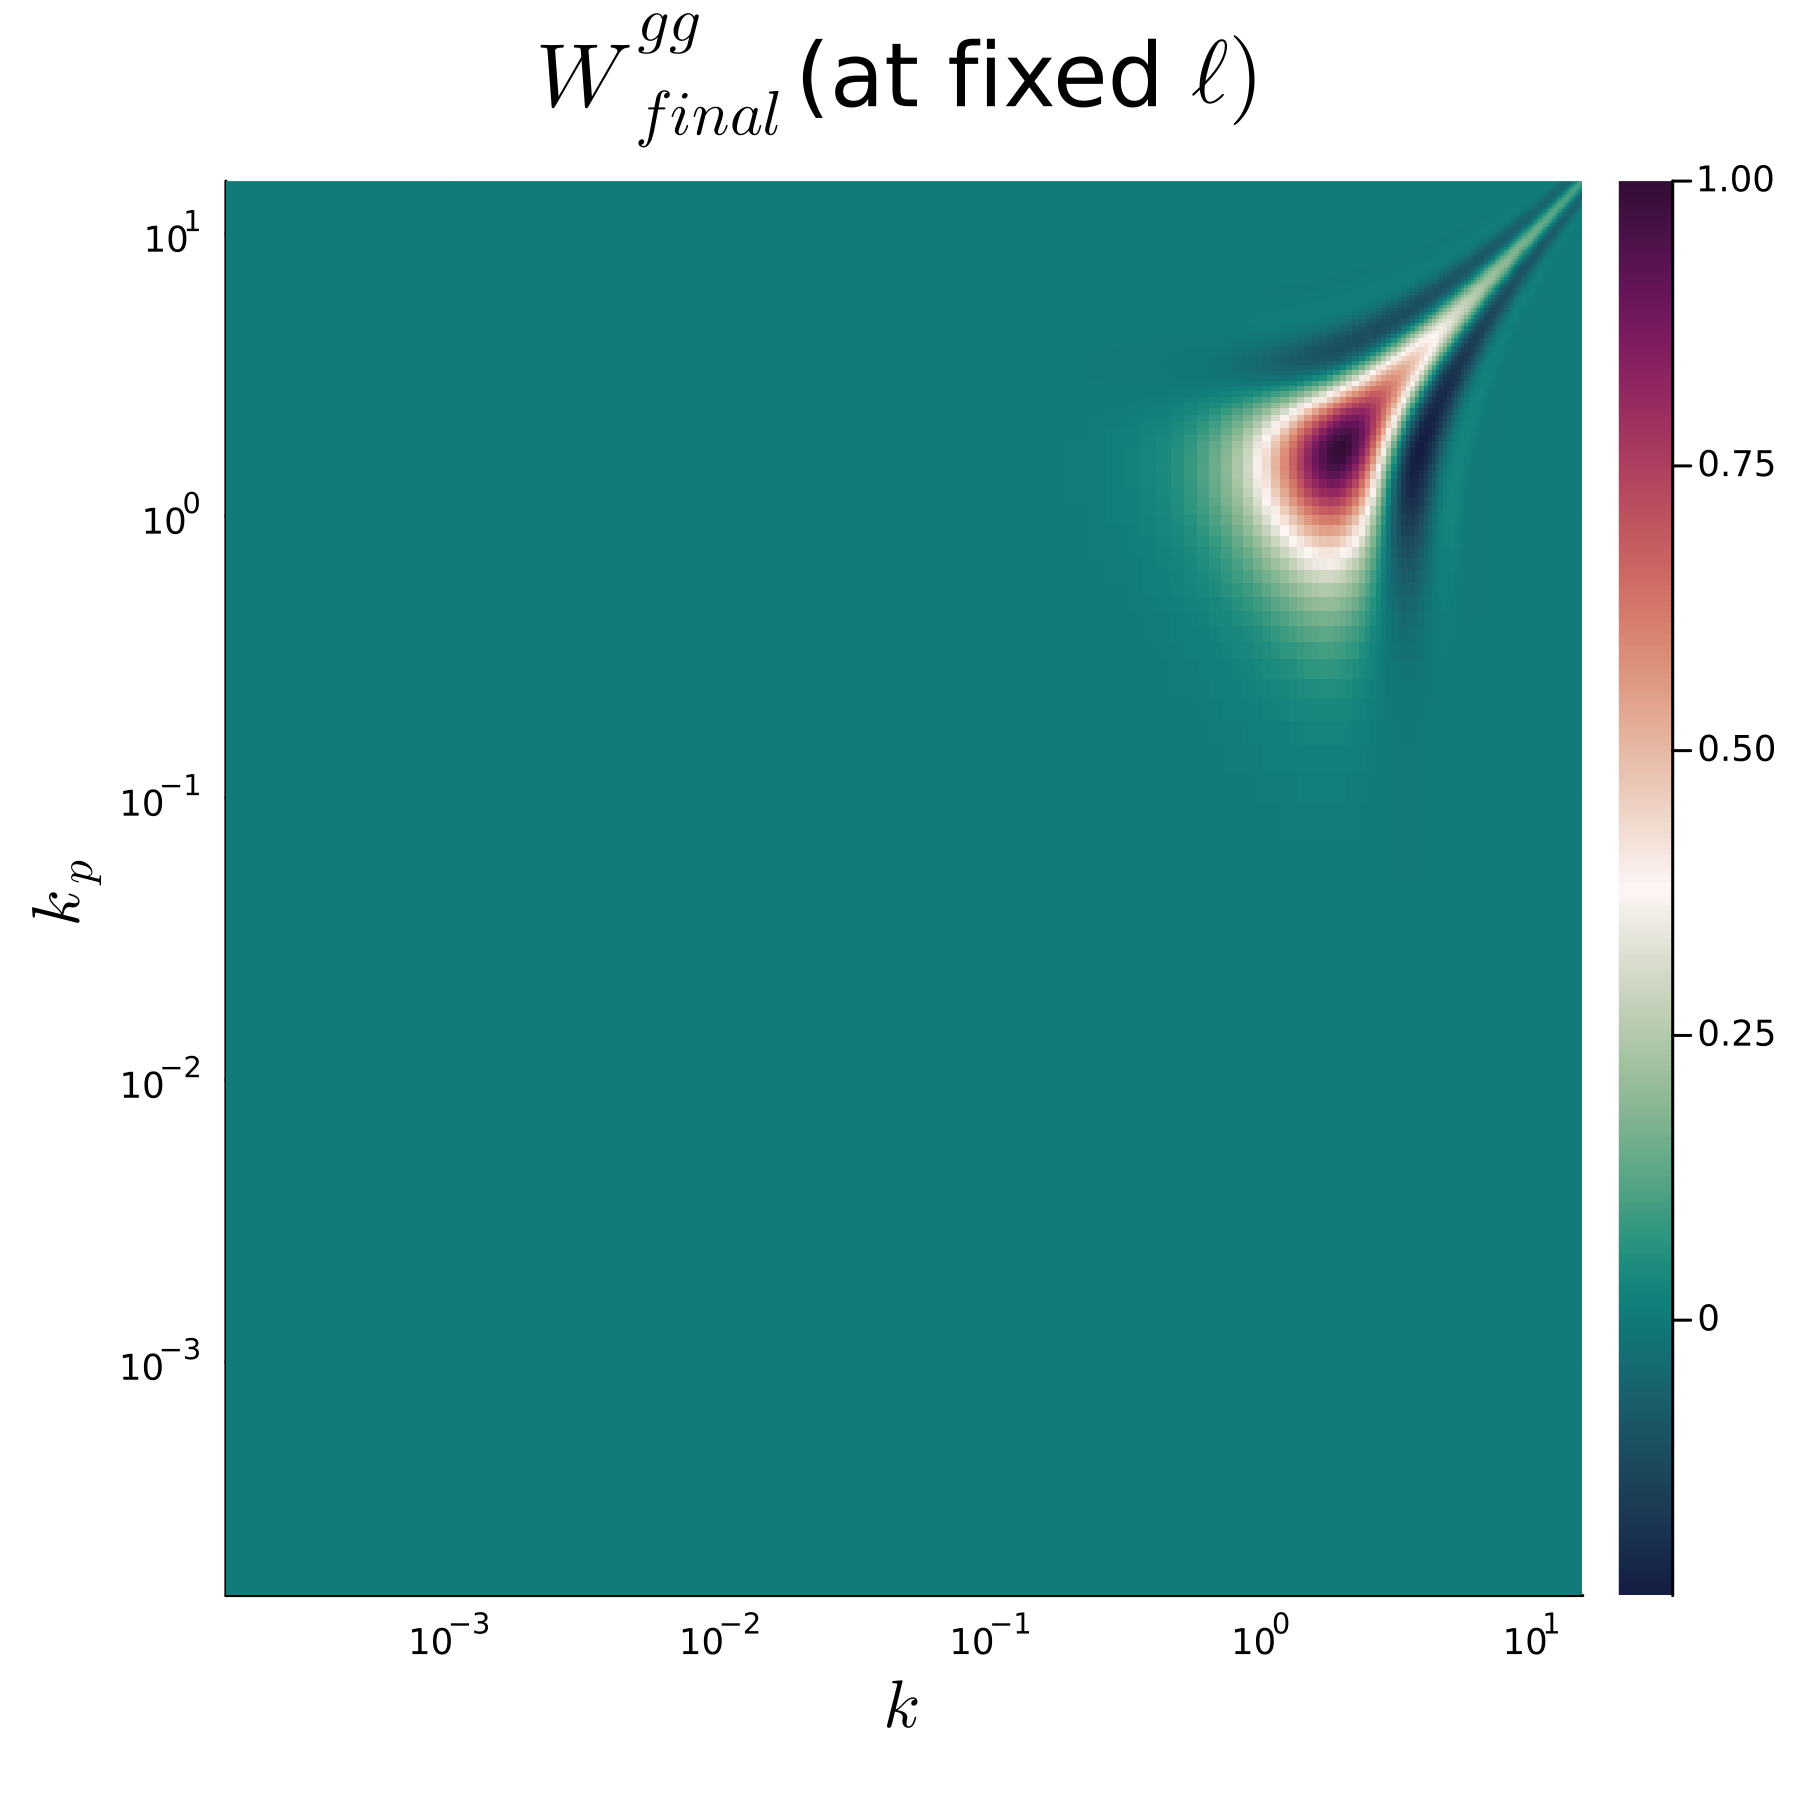

In [988]:
idx = sortperm(k_grid)
idx_p = sortperm(kp_grid)

# genera tick automatici alle potenze di 10 nel range dei dati
xticks_vals = 10.0 .^ (floor(log10(minimum(k_grid))):ceil(log10(maximum(k_grid))))
yticks_vals = 10.0 .^ (floor(log10(minimum(kp_grid))):ceil(log10(maximum(kp_grid))))

heatmap(k_grid[idx], kp_grid[idx_p],
        W_final_gal[1,idx,idx_p]/maximum(W_final_gal[1,idx,idx_p]),
        size = size_heatmap, title=L"W_{final}^{gg}"*"(at fixed "*L"ℓ)",
        c = :curl, xlabel=L"k", ylabel=L"k_p",
        yguidefontsize=15, xguidefontsize=15, titlefontsize=20,
        dpi = 300,
        xscale = :log10, yscale = :log10,
        xticks = xticks_vals, yticks = yticks_vals
        )


In [879]:
savefig(joinpath(plot_subdir, "Sl_plots/k_grid_sorted_k_grid_sorted.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_06_185325/plots/Sl_plots/k_grid_sorted_k_grid_sorted.png"

In [880]:
println(size(W_tilde))

(150, 150, 200, 100)


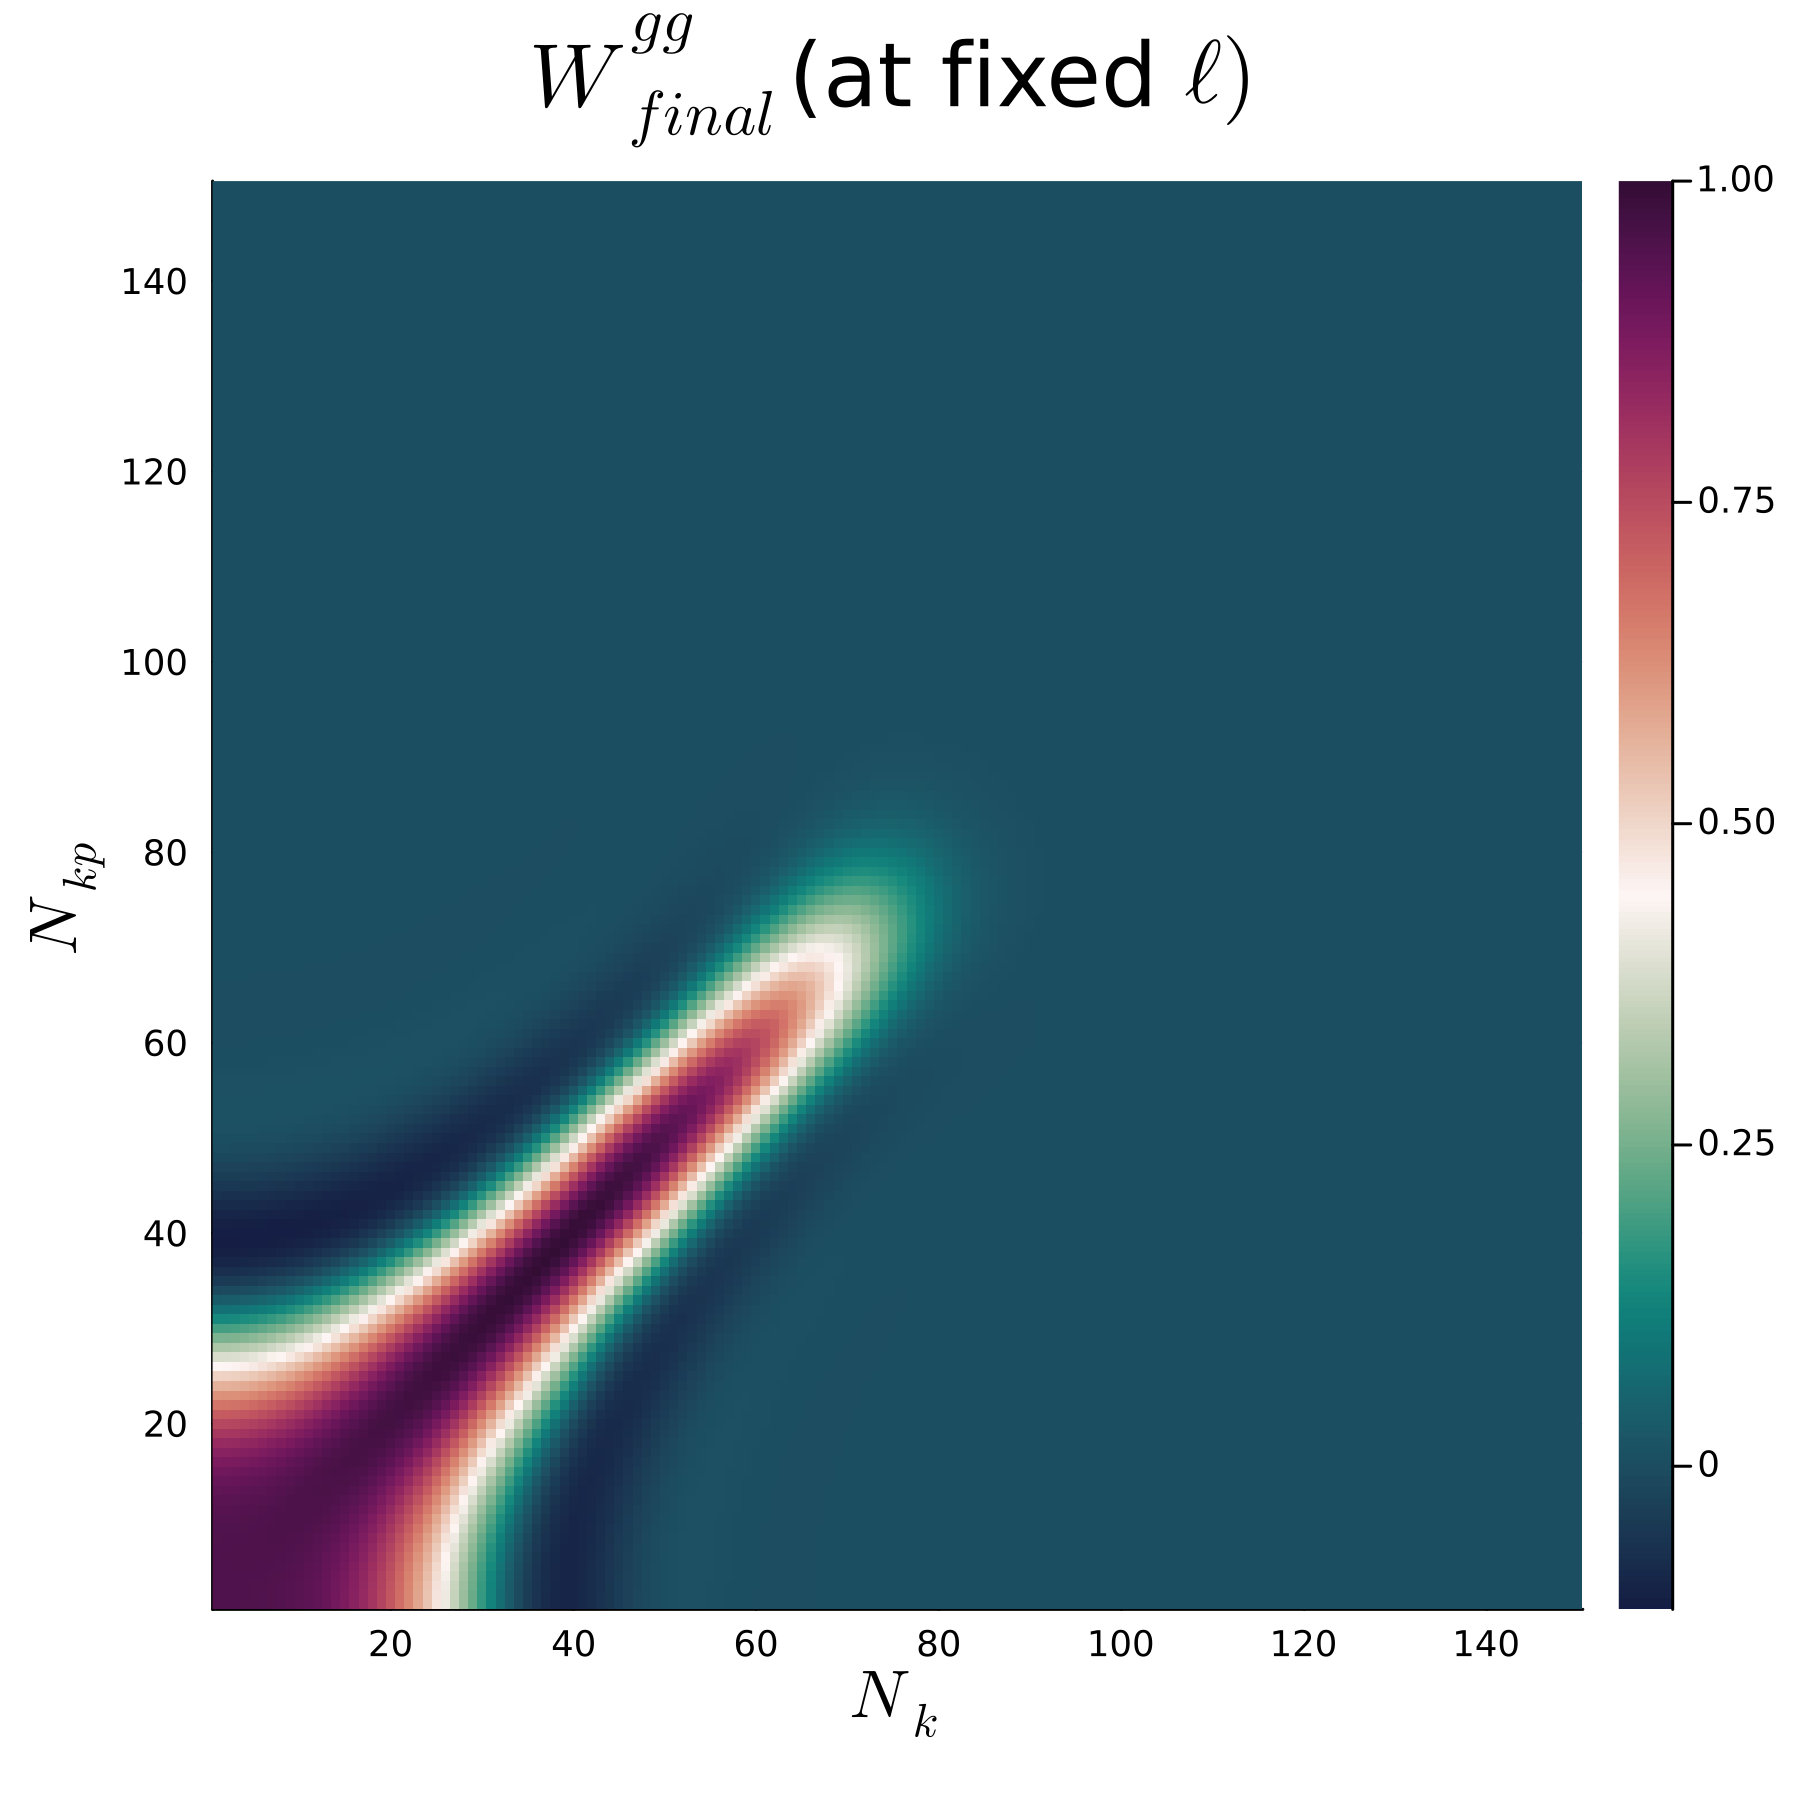

In [989]:
heatmap(1:Nk, 1:Nkp, W_final_gal[10,:,:]/maximum(W_final_gal[10,:,:]), 
    size = size_heatmap, 
    title = L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
    c = :curl, 
    xlabel = L"N_k", ylabel = L"N_{kp}", 
    colorbar = true,
    yguidefontsize = 15, xguidefontsize = 15, titlefontsize = 20,
    dpi = 300)


In [882]:
savefig(joinpath(plot_subdir, "Sl_plots/Nk_Nkp.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_06_185325/plots/Sl_plots/Nk_Nkp.png"

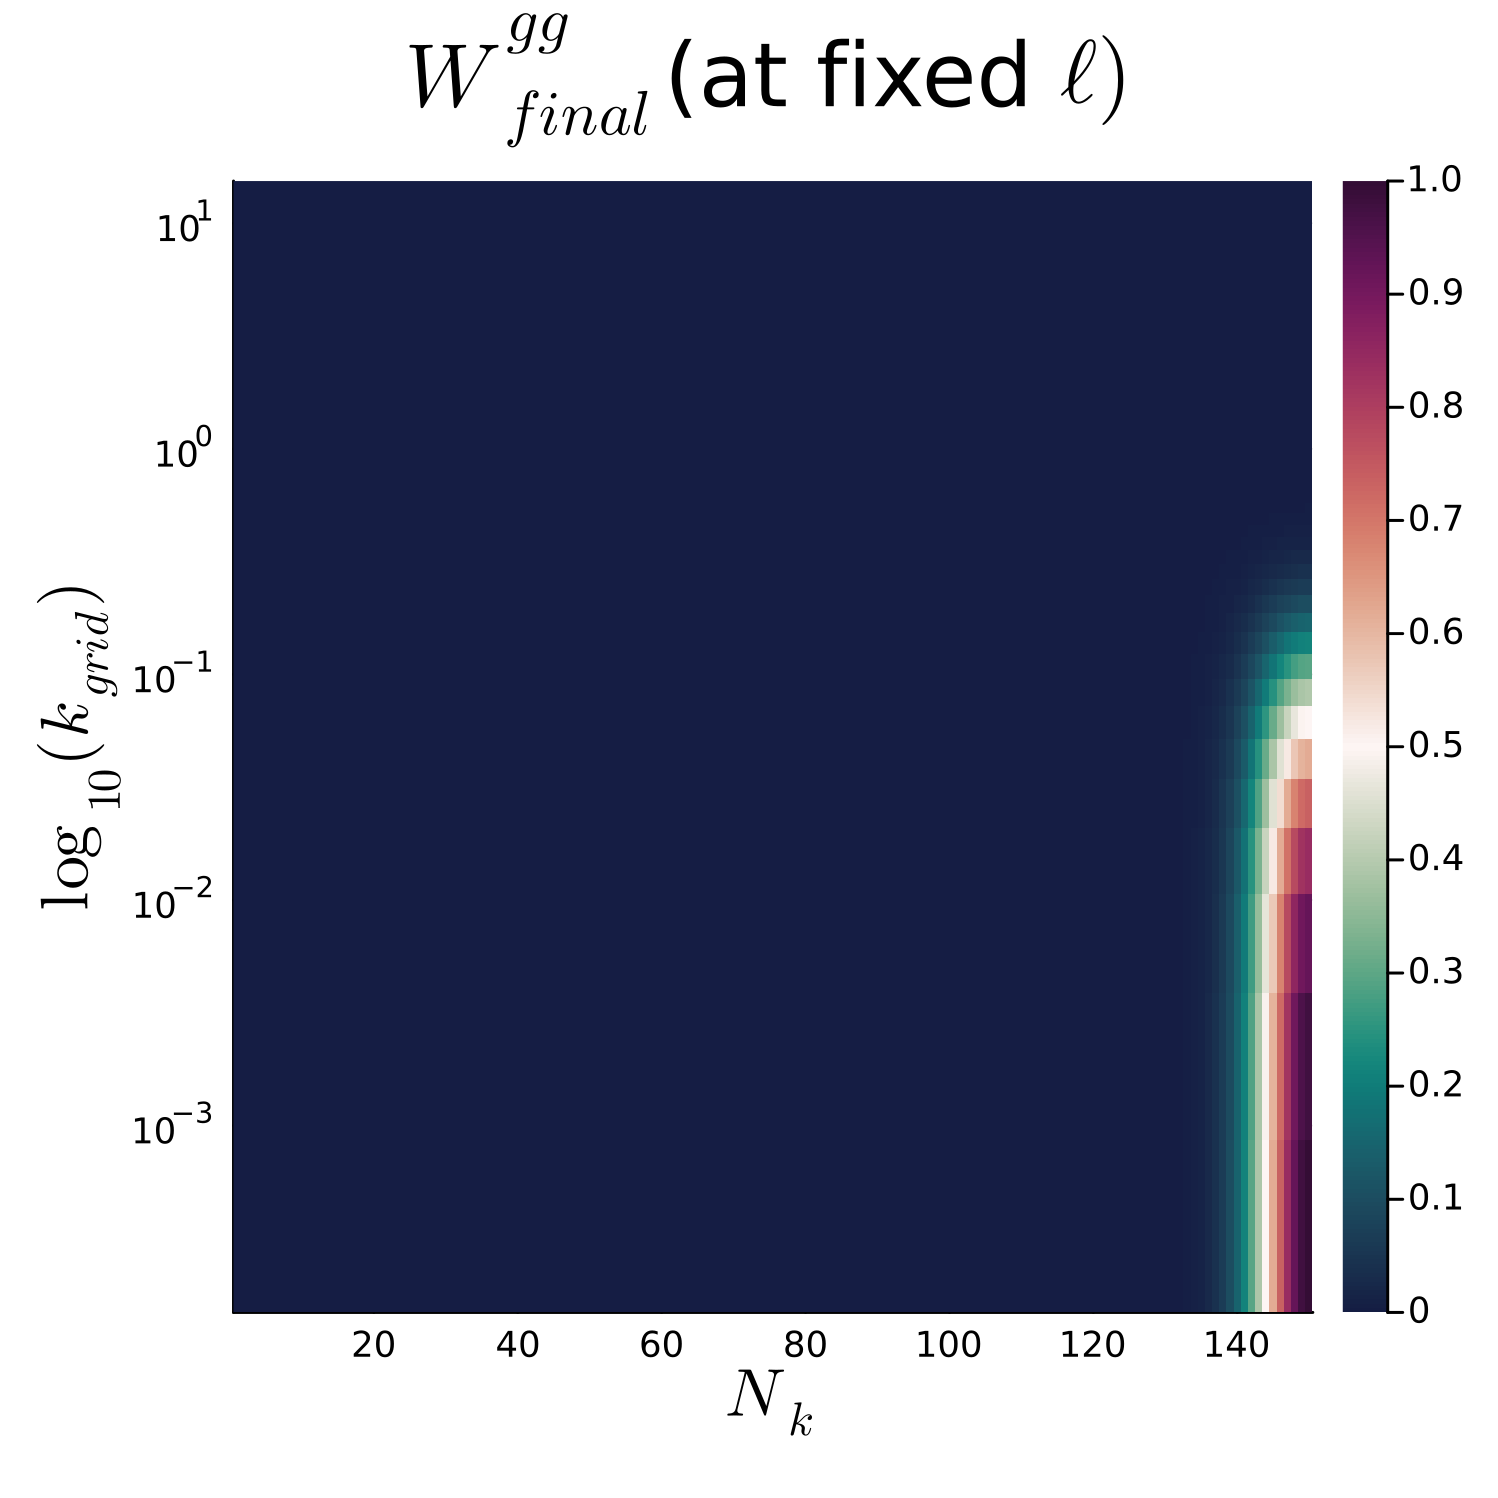

In [ ]:
idx_p = sortperm(kp_grid)
yticks_vals = 10.0 .^ (floor(log10(minimum(k_grid))):ceil(log10(maximum(k_grid))))
heatmap(1:Nk, 
        kp_grid[idx_p], 
        W_final_gal[90, :, idx_p] / maximum(W_final_gal[90, :, idx_p]), 
        size = size_heatmap, title = L"W_{final}^{gg}"*"(at fixed "*L"ℓ)", 
        c = :curl, xlabel = L"N_k", ylabel = L"\log_{10}(k_{grid})",
        yguidefontsize = 15, xguidefontsize = 15, titlefontsize = 20, dpi = 300,
        yscale = :log10, yticks = yticks_vals
        )



In [884]:
savefig(joinpath(plot_subdir, "Sl_plots/Nk_kp_grid_sorted.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_06_185325/plots/Sl_plots/Nk_kp_grid_sorted.png"

In [885]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k_pk = pk_dict["k"]
z_pk = pk_dict["z"]
#Interpolating the power spectrum: Linear P(k) - Non-linear P(k)
y_pk = LinRange(log10(first(k_pk)),log10(last(k_pk)), length(k_pk))
x_pk = LinRange(first(z_pk), last(z_pk), length(z_pk))
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm = scale(InterpPmm, (x_pk, y_pk))
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x_pk, y_pk)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())
power_spectrum(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm(z_of_χ(χ2),log10(k_pk)))
power_spectrum_nl(k_pk, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k_pk)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k_pk)))

power_spectrum_nl (generic function with 1 method)

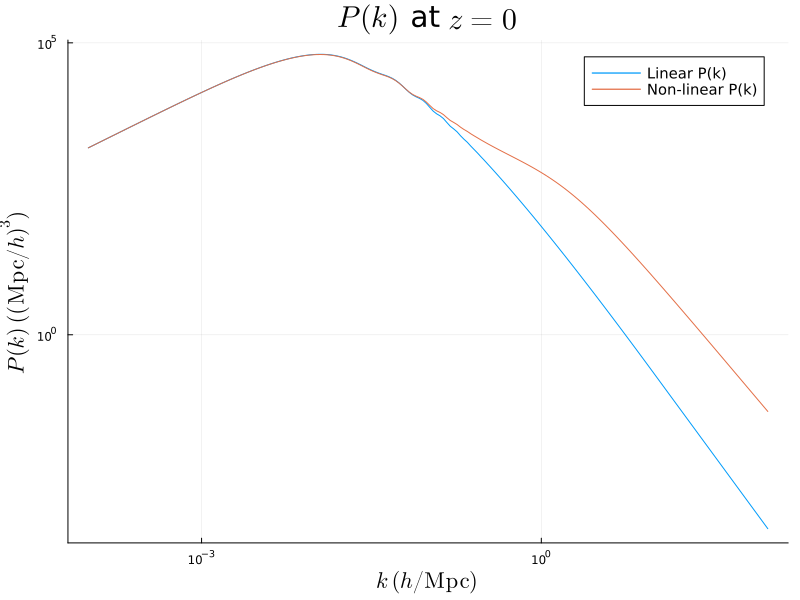

In [ ]:
plot(k_pk, power_spectrum.(k_pk, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k_pk, power_spectrum_nl.(k_pk, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10,
      size=size_plot,
      legendfontsize=10)

get_clencurt_grid produces the node of Clenshaw-Curtis mapped on [$k_{min}$, $k_{max}$]. \
get_clencurt_weights produces the corresponding quadrature weights scaled to the interval [-1,1]. \

In [887]:
Pk_grid = power_spectrum.(k_grid, kmin, kmax)
w_k = Blast.get_clencurt_weights(kmin, kmax, Nk)
weight_gal = w_k .* k_grid.^2 .* Pk_grid 
;

In [888]:
abstract type AbstractProbe end
struct Galaxy <: AbstractProbe end
struct Shear <: AbstractProbe end
factorial_frac(ℓ) = (ℓ + 2.0) * (ℓ + 1.0) * ℓ * (ℓ - 1.0)
get_ell_prefactor(::Galaxy, ::Galaxy, ℓ) = @. (2 / π) * ones(length(ℓ))
get_ell_prefactor(::Galaxy, ::Shear,  ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Galaxy, ℓ) = @. (2 / π) * sqrt(factorial_frac(ℓ))
get_ell_prefactor(::Shear,  ::Shear,  ℓ) = @. (2 / π) * factorial_frac(ℓ)
pref_gg = get_ell_prefactor(Galaxy(), Galaxy(), ℓ)
pref_gg = reduce(vcat, pref_gg)
pref_gs = get_ell_prefactor(Galaxy(), Shear(), ℓ)
pref_gs = reduce(vcat, pref_gs)
pref_gg = reduce(vcat, pref_gg)
pref_ss = get_ell_prefactor(Shear(), Shear(), ℓ)
pref_ss = reduce(vcat, pref_ss);

In [889]:
println("SIZES")
println("weight_gal -> ", size(weight_gal))
println("W_final_gal -> ", size(W_final_gal))
println("pref_gg -> ", size(pref_gg), "\npref_ss -> ", size(pref_ss), "\npref_gs -> ", size(pref_gs))

SIZES
weight_gal -> (150,)
W_final_gal -> (100, 150, 150)
pref_gg -> (100,)
pref_ss -> (100,)
pref_gs -> (100,)


In [890]:
S_lkk_gg = zeros(Float64, size(W_final_gal, 3), size(W_final_gal, 3), length(ℓ))
# k1 and k2 are alredy inside the W_tilde (for now, equal to k. and also k1 = k2)
@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp]
#@tullio S_lkk_gg[kp, kpp, li] = pref_gg[li] * weight_gal[k] * W_final_gal[li, k, kp] * W_final_gal[li, k, kpp] * kp_grid[kp] * kp_grid[kpp]
println("Size of S_l (kp, kpp) (gal-gal):  ", size(S_lkk_gg))
npzwrite(joinpath(quantity_subdir, "Sl/S_lkk_gg.npy"), S_lkk_gg)
;

Size of S_l (kp, kpp) (gal-gal):  (150, 150, 100)


wavenumber k as a function of $\ell$ through $k \approx \frac{\ell+0.5}{\chi}$ ?

In [966]:
xref = (xmax - xmin ) * 0.5
ℓ_to_k = ℓ -> ℓ ./ xref
ℓ_ticks = 1:50:200
k_ticks = ℓ_to_k.(ℓ_ticks)
k_ticklabels = [string(round(k, digits=3)) for k in k_ticks];

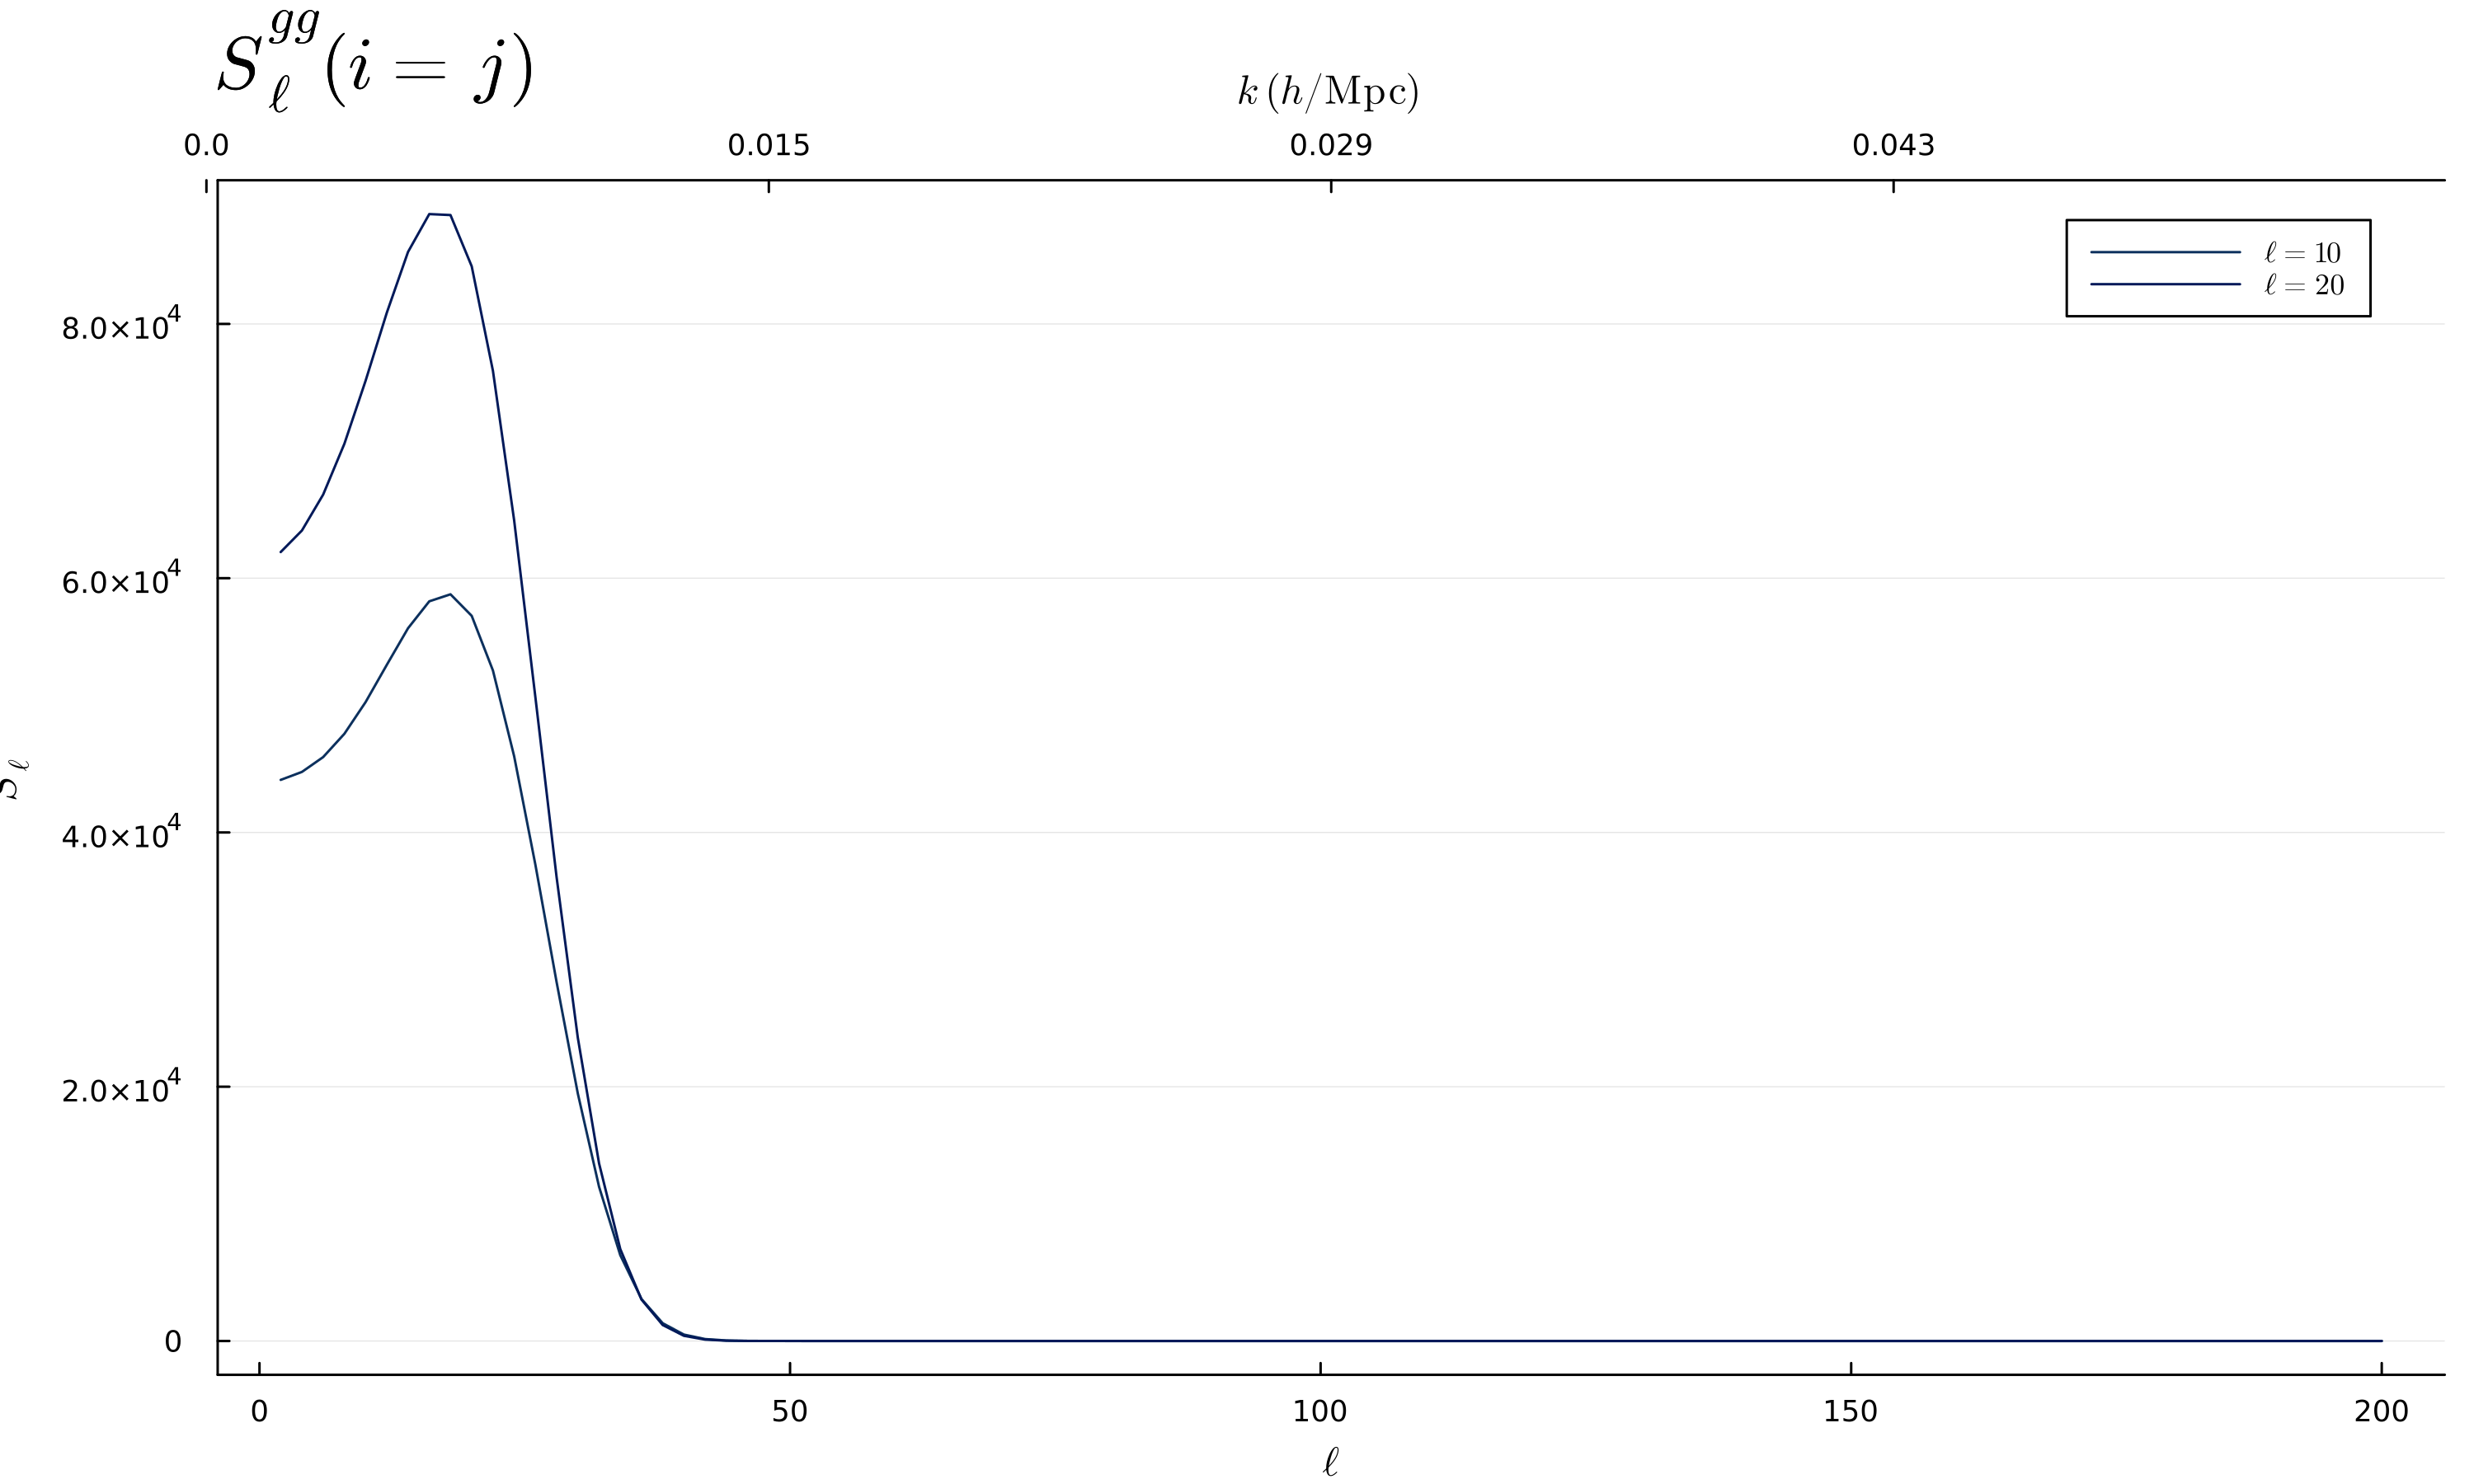

In [ ]:
plot(ℓ, S_lkk_gg[10,10,:],
      color = colors[10],
      label = L"\ell=10")
plot!(ℓ, S_lkk_gg[20,20,:],
      color = colors[1],
      label = L"\ell=20")

plot!(xaxis = L"\ell",
      ylabel = L"S_\ell",
     )
plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      xlims = (minimum(ℓ), maximum(ℓ)),
      label = ""
     )
plot!(label = "Beyond BLAST", 
      size = size_plot,
      title = L"S_\ell^{gg} (i = j)",
      titlefontsize = 20,
      titleposition = :left,
      margin = 10mm,
      dpi = 300)

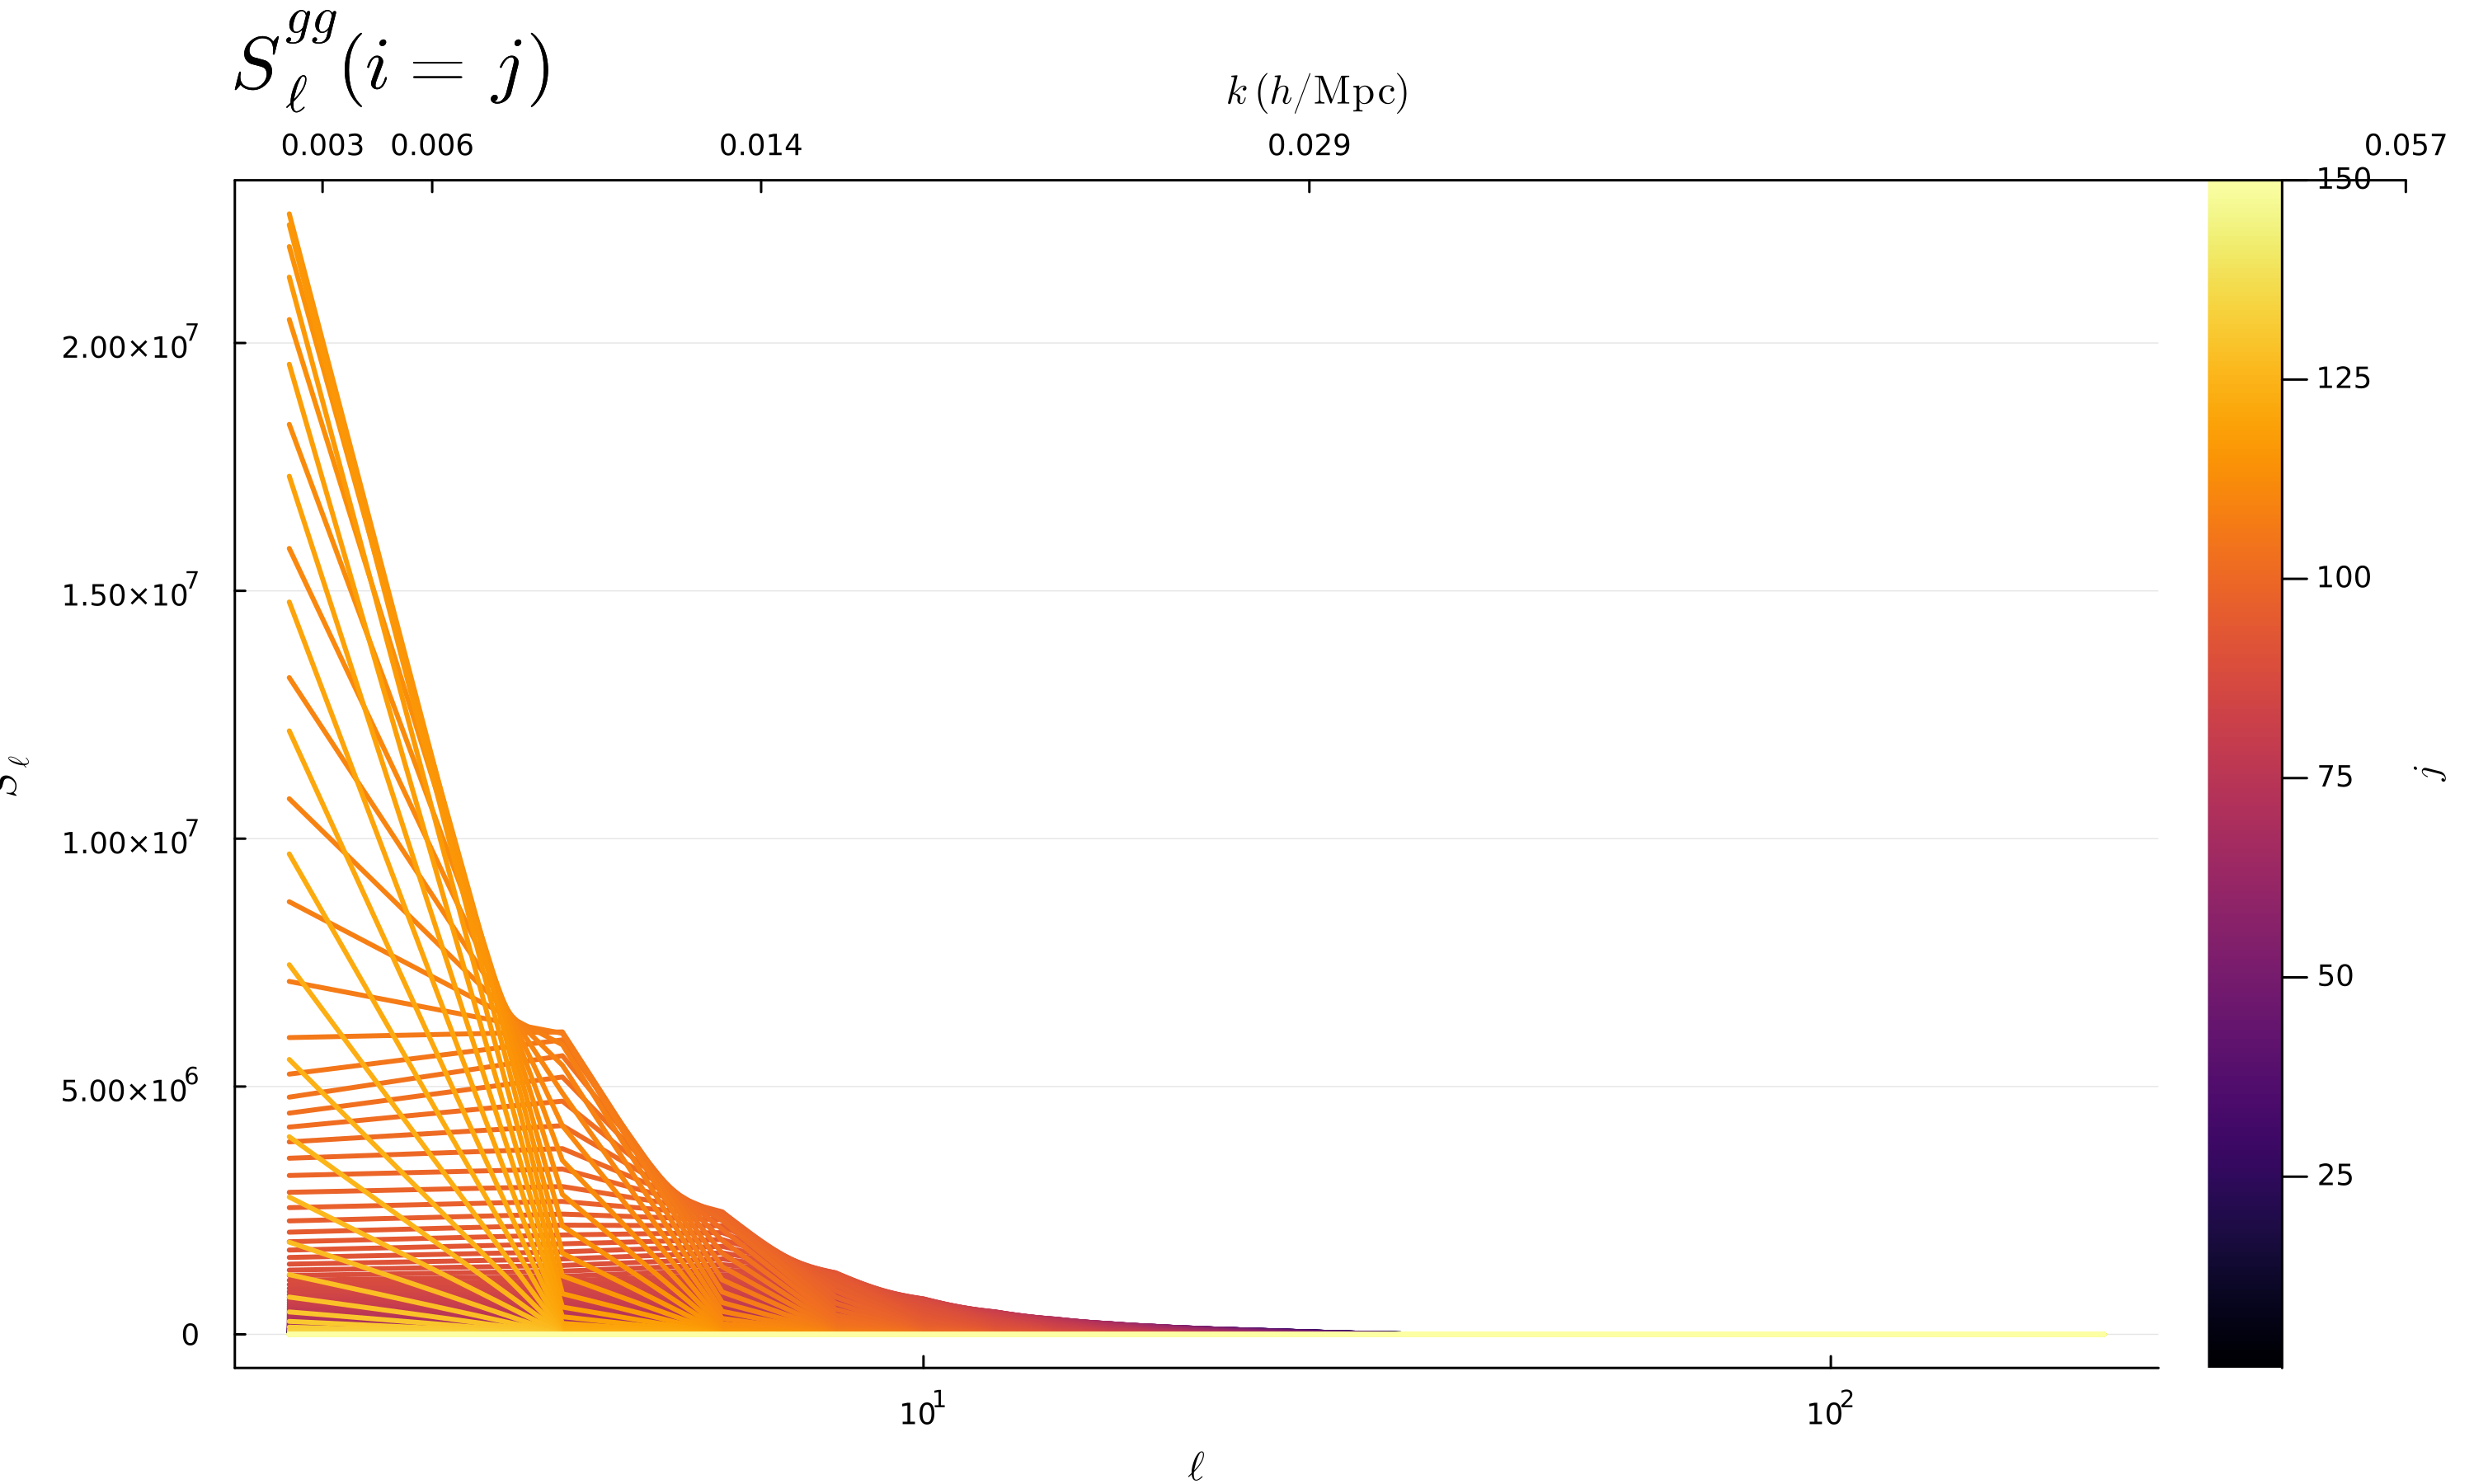

In [ ]:
colors = palette(:batlow, Nkp)

plt = plot()

for i in 1:Nkp
    plot!(plt, ℓ, S_lkk_gg[i,i,:], line_z = i,
          label = L"i = %$(i)",
          color = colors[i], linewidth = 2)
end

plot!(plt, label="Beyond BLAST", 
     xaxis=L"\ell", ylabel=L"S_\ell", 
     xscale = :log10
    )
plot!(twiny(),
      xaxis = L"k \; (h/\mathrm{Mpc})",
      xticks = (ℓ_ticks, k_ticklabels),
      xlims = (minimum(ℓ), maximum(ℓ)),
      label = ""
     )
plot!(legend = false, colorbar = true, colorbar_title = L"j",
      clims = (1, Nkp),
      size=size_plot, titlefontsize=20, 
      margin = 10mm,
      dpi = 300,
      titleposition = :left,
      title=L"S_\ell^{gg} (i = j)"
     )
plt

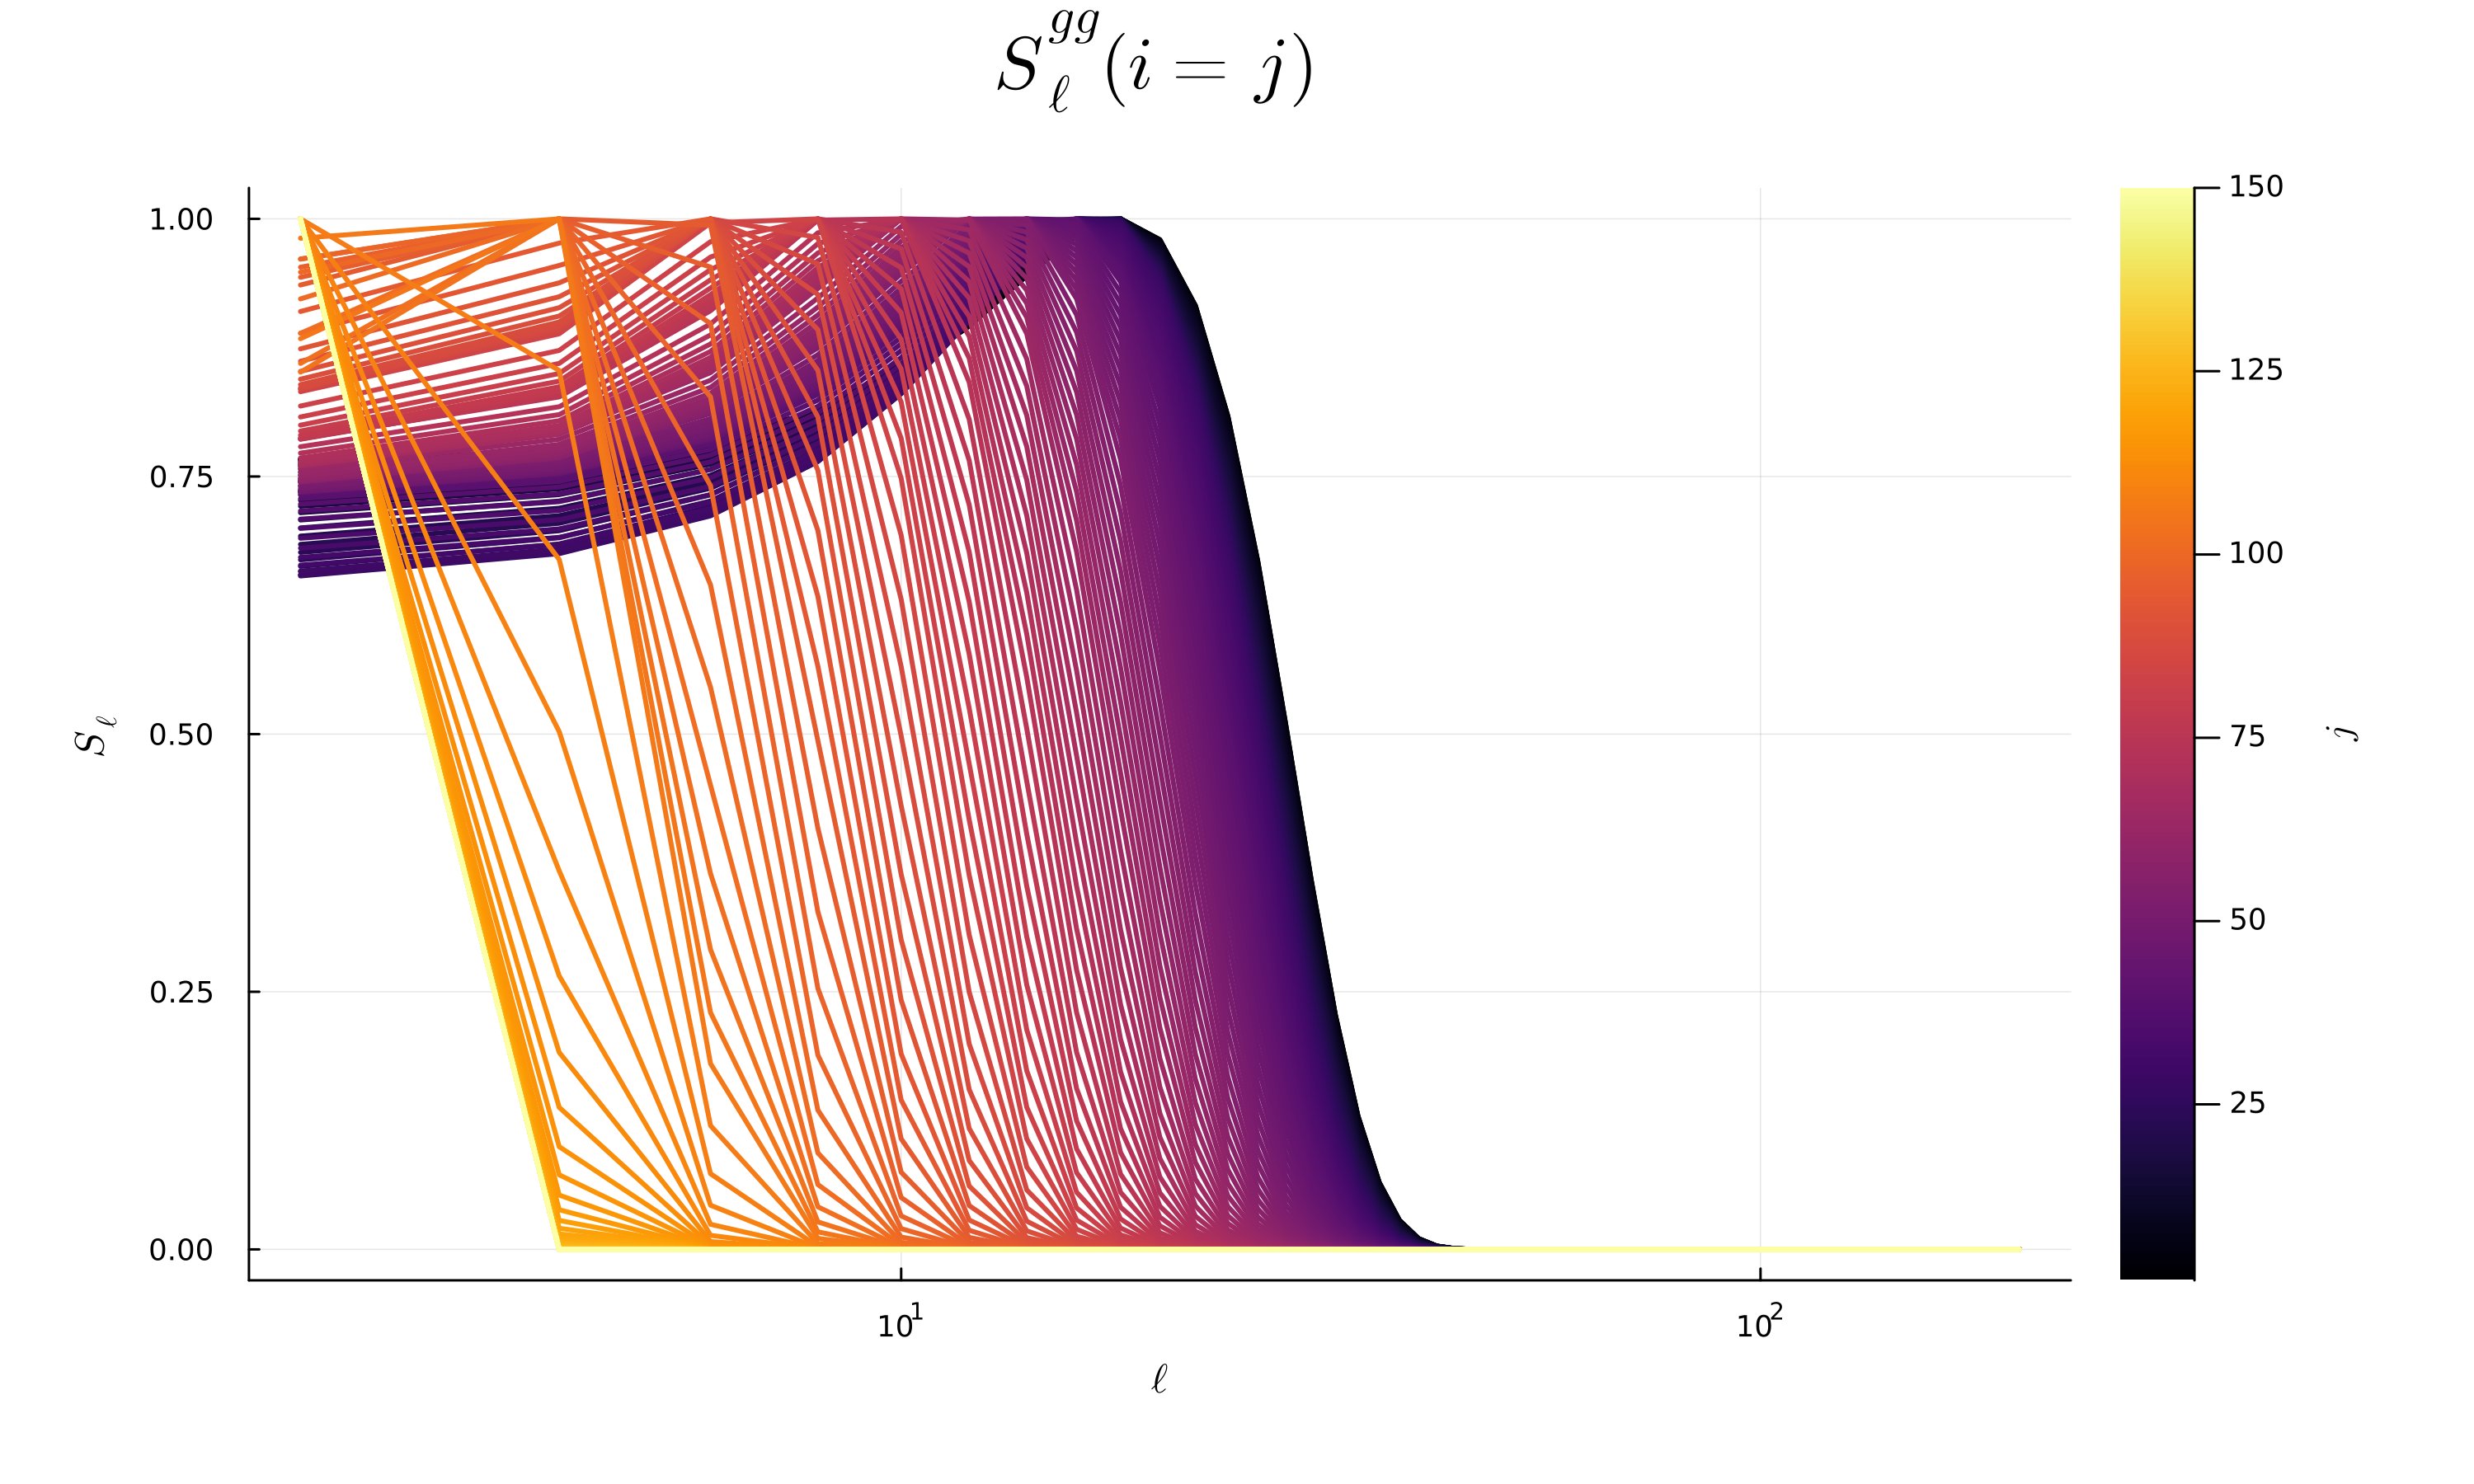

In [ ]:
colors = palette(:batlow, Nkp)

plt = plot()

for i in 1:Nkp
    plot!(plt, ℓ, S_lkk_gg[i,i,:]/maximum(S_lkk_gg[i,i,:]), line_z = i,
          label = L"i = %$(i)",
          color = colors[i], linewidth = 2)
end

plot!(plt, label="Beyond BLAST", 
    legend = false, colorbar = true, colorbar_title = L"j",
    clims = (1, Nkp),
    xlabel=L"\ell", ylabel=L"S_\ell", 
    title=L"S_\ell^{gg} (i = j)",
    size=size_plot, titlefontsize=20, 
    margin = 10mm,
    dpi = 300
    ,xscale = :log10
    )

plt

In [894]:
savefig(joinpath(plot_subdir, "Sl_plots/S_lkk_gg_fixed_l_various.png"))

"/Users/anvi/Desktop/cosmo/notebooks/out/runs/run_2026_07_06_185325/plots/Sl_plots/S_lkk_gg_fixed_l_various.png"

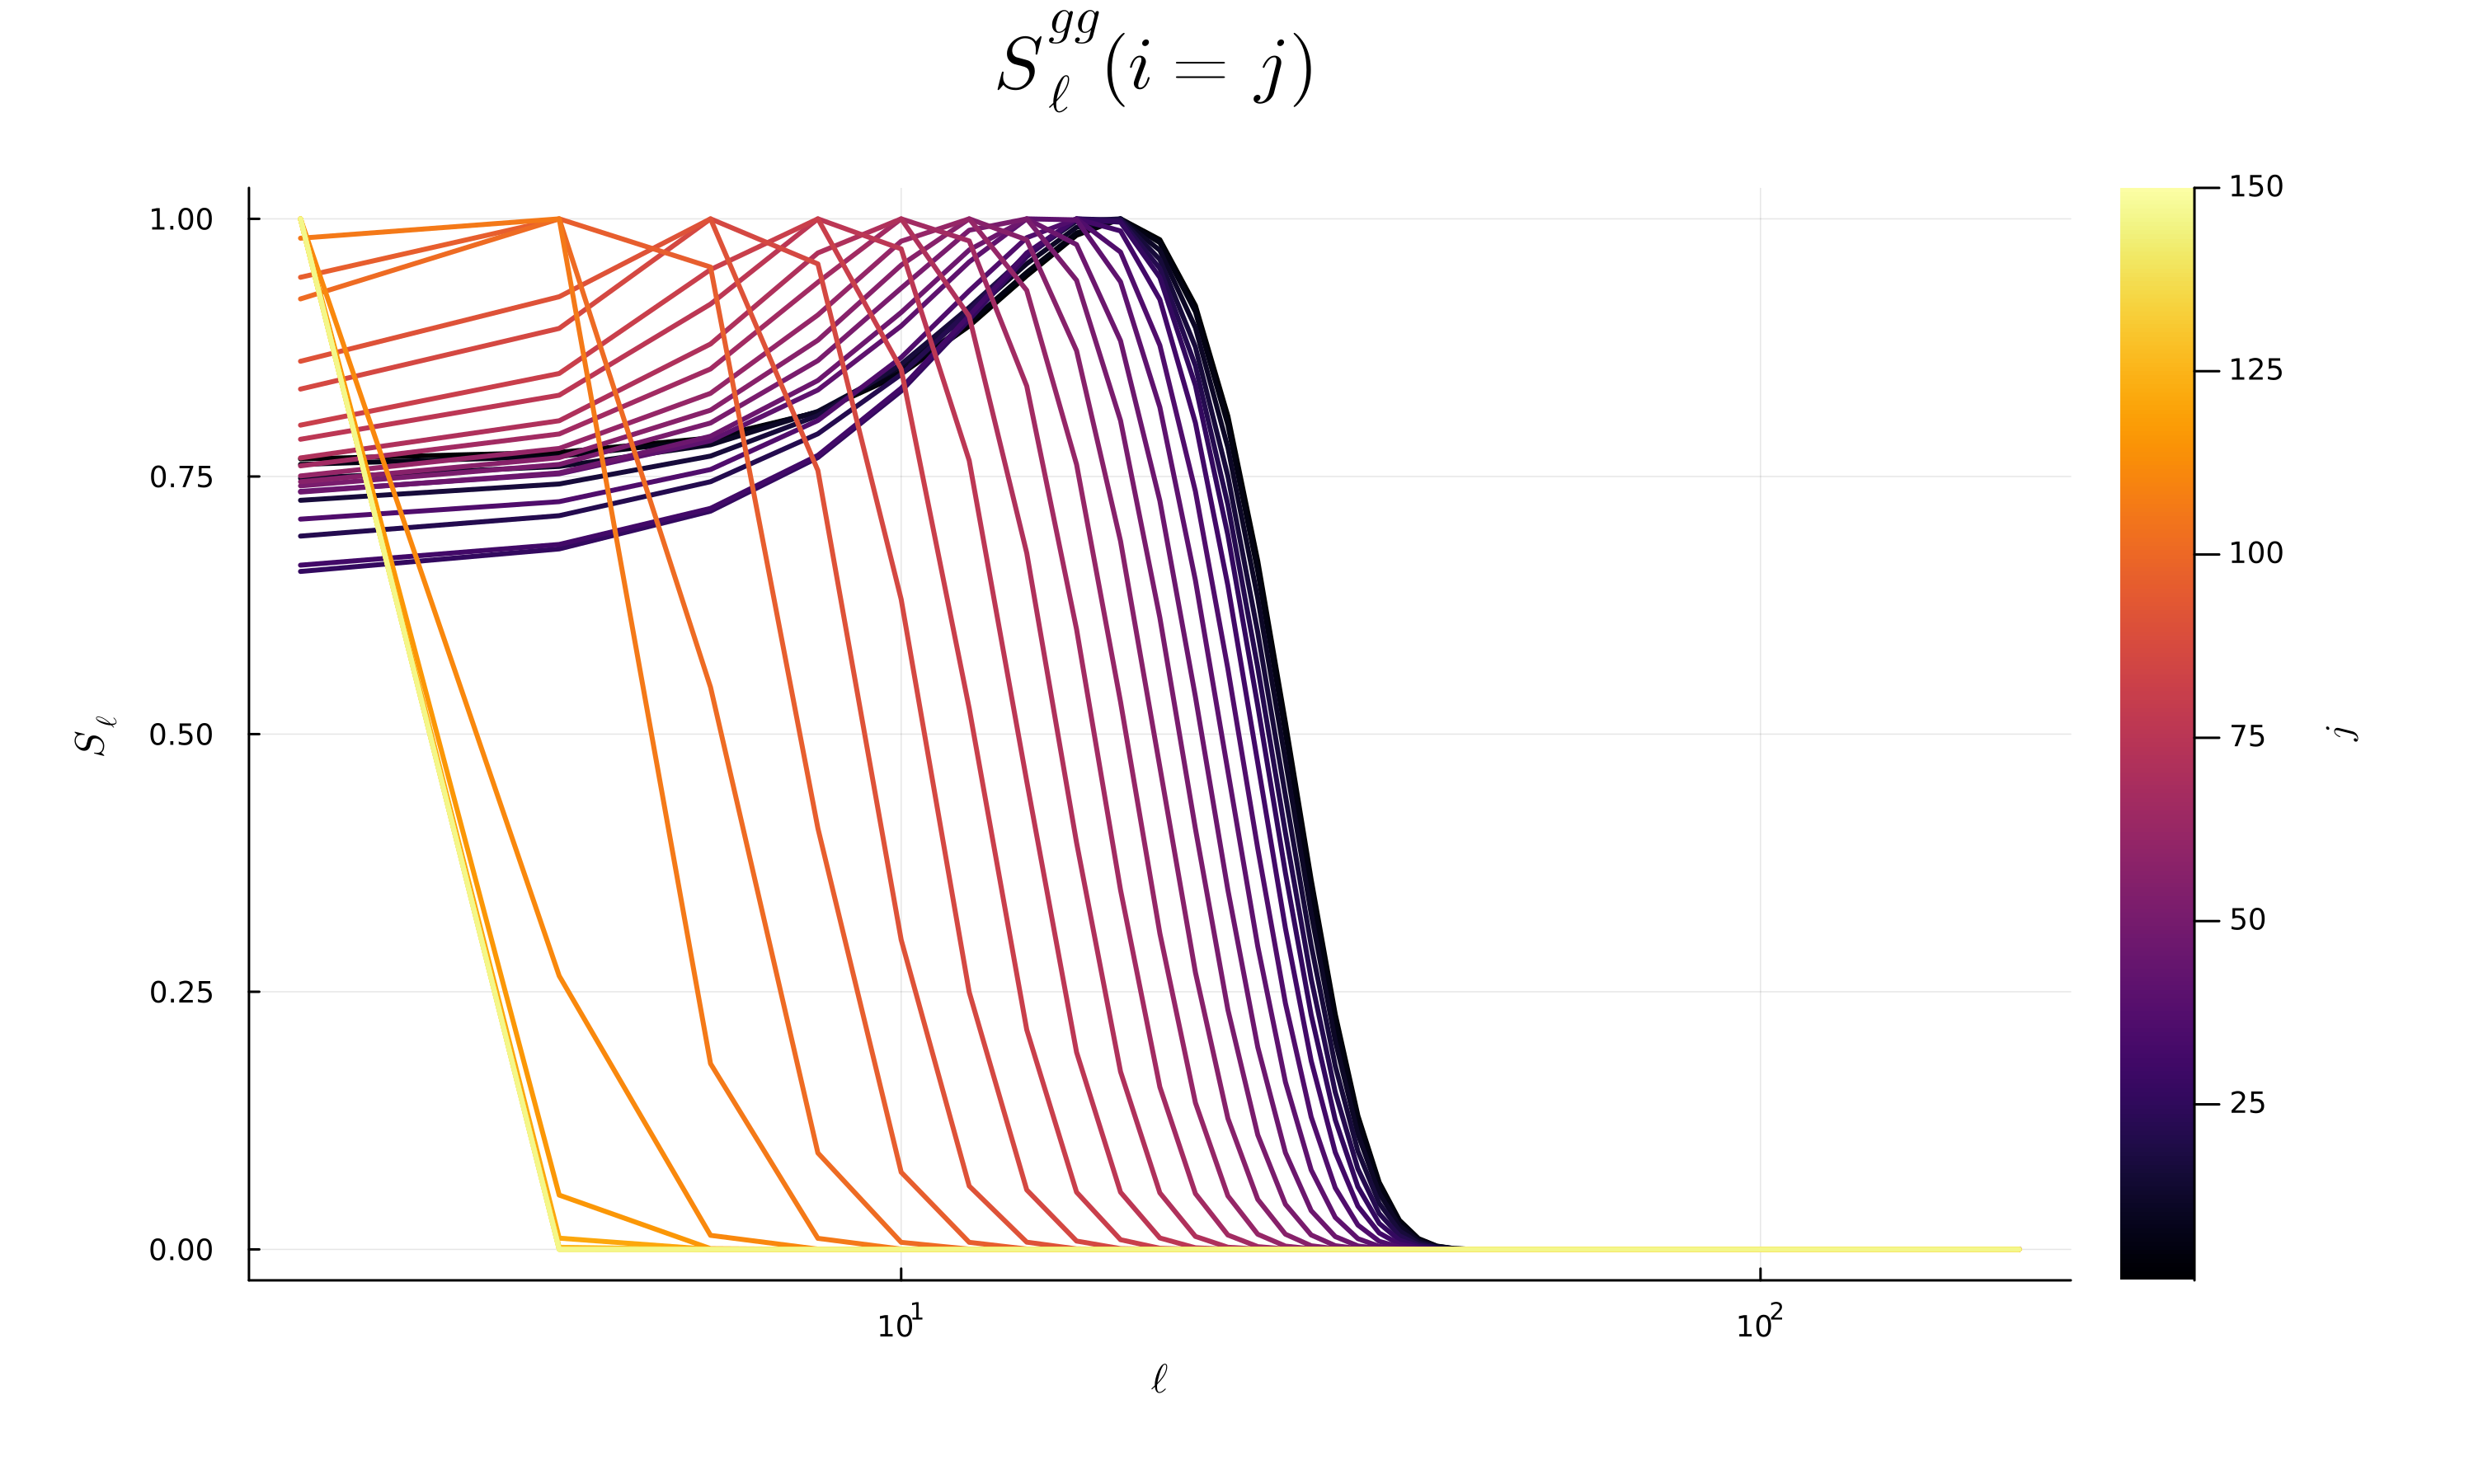

In [ ]:
colors = palette(:batlow, Nkp)

plt = plot()

a = 1:5:150
for i in a
    plot!(plt, ℓ, S_lkk_gg[i,i,:]/maximum(S_lkk_gg[i,i,:]), line_z = i,
          label = L"i = %$(i)",
          color = colors[i], linewidth = 2)
end

plot!(plt, label="Beyond BLAST", 
    legend = false, colorbar = true, colorbar_title = L"j",
    clims = (1, Nkp),
    xlabel=L"\ell", ylabel=L"S_\ell", 
    title=L"S_\ell^{gg} (i = j)",
    size=size_plot, titlefontsize=20, 
    margin = 10mm,
    dpi = 300
    ,xscale = :log10
    )

plt

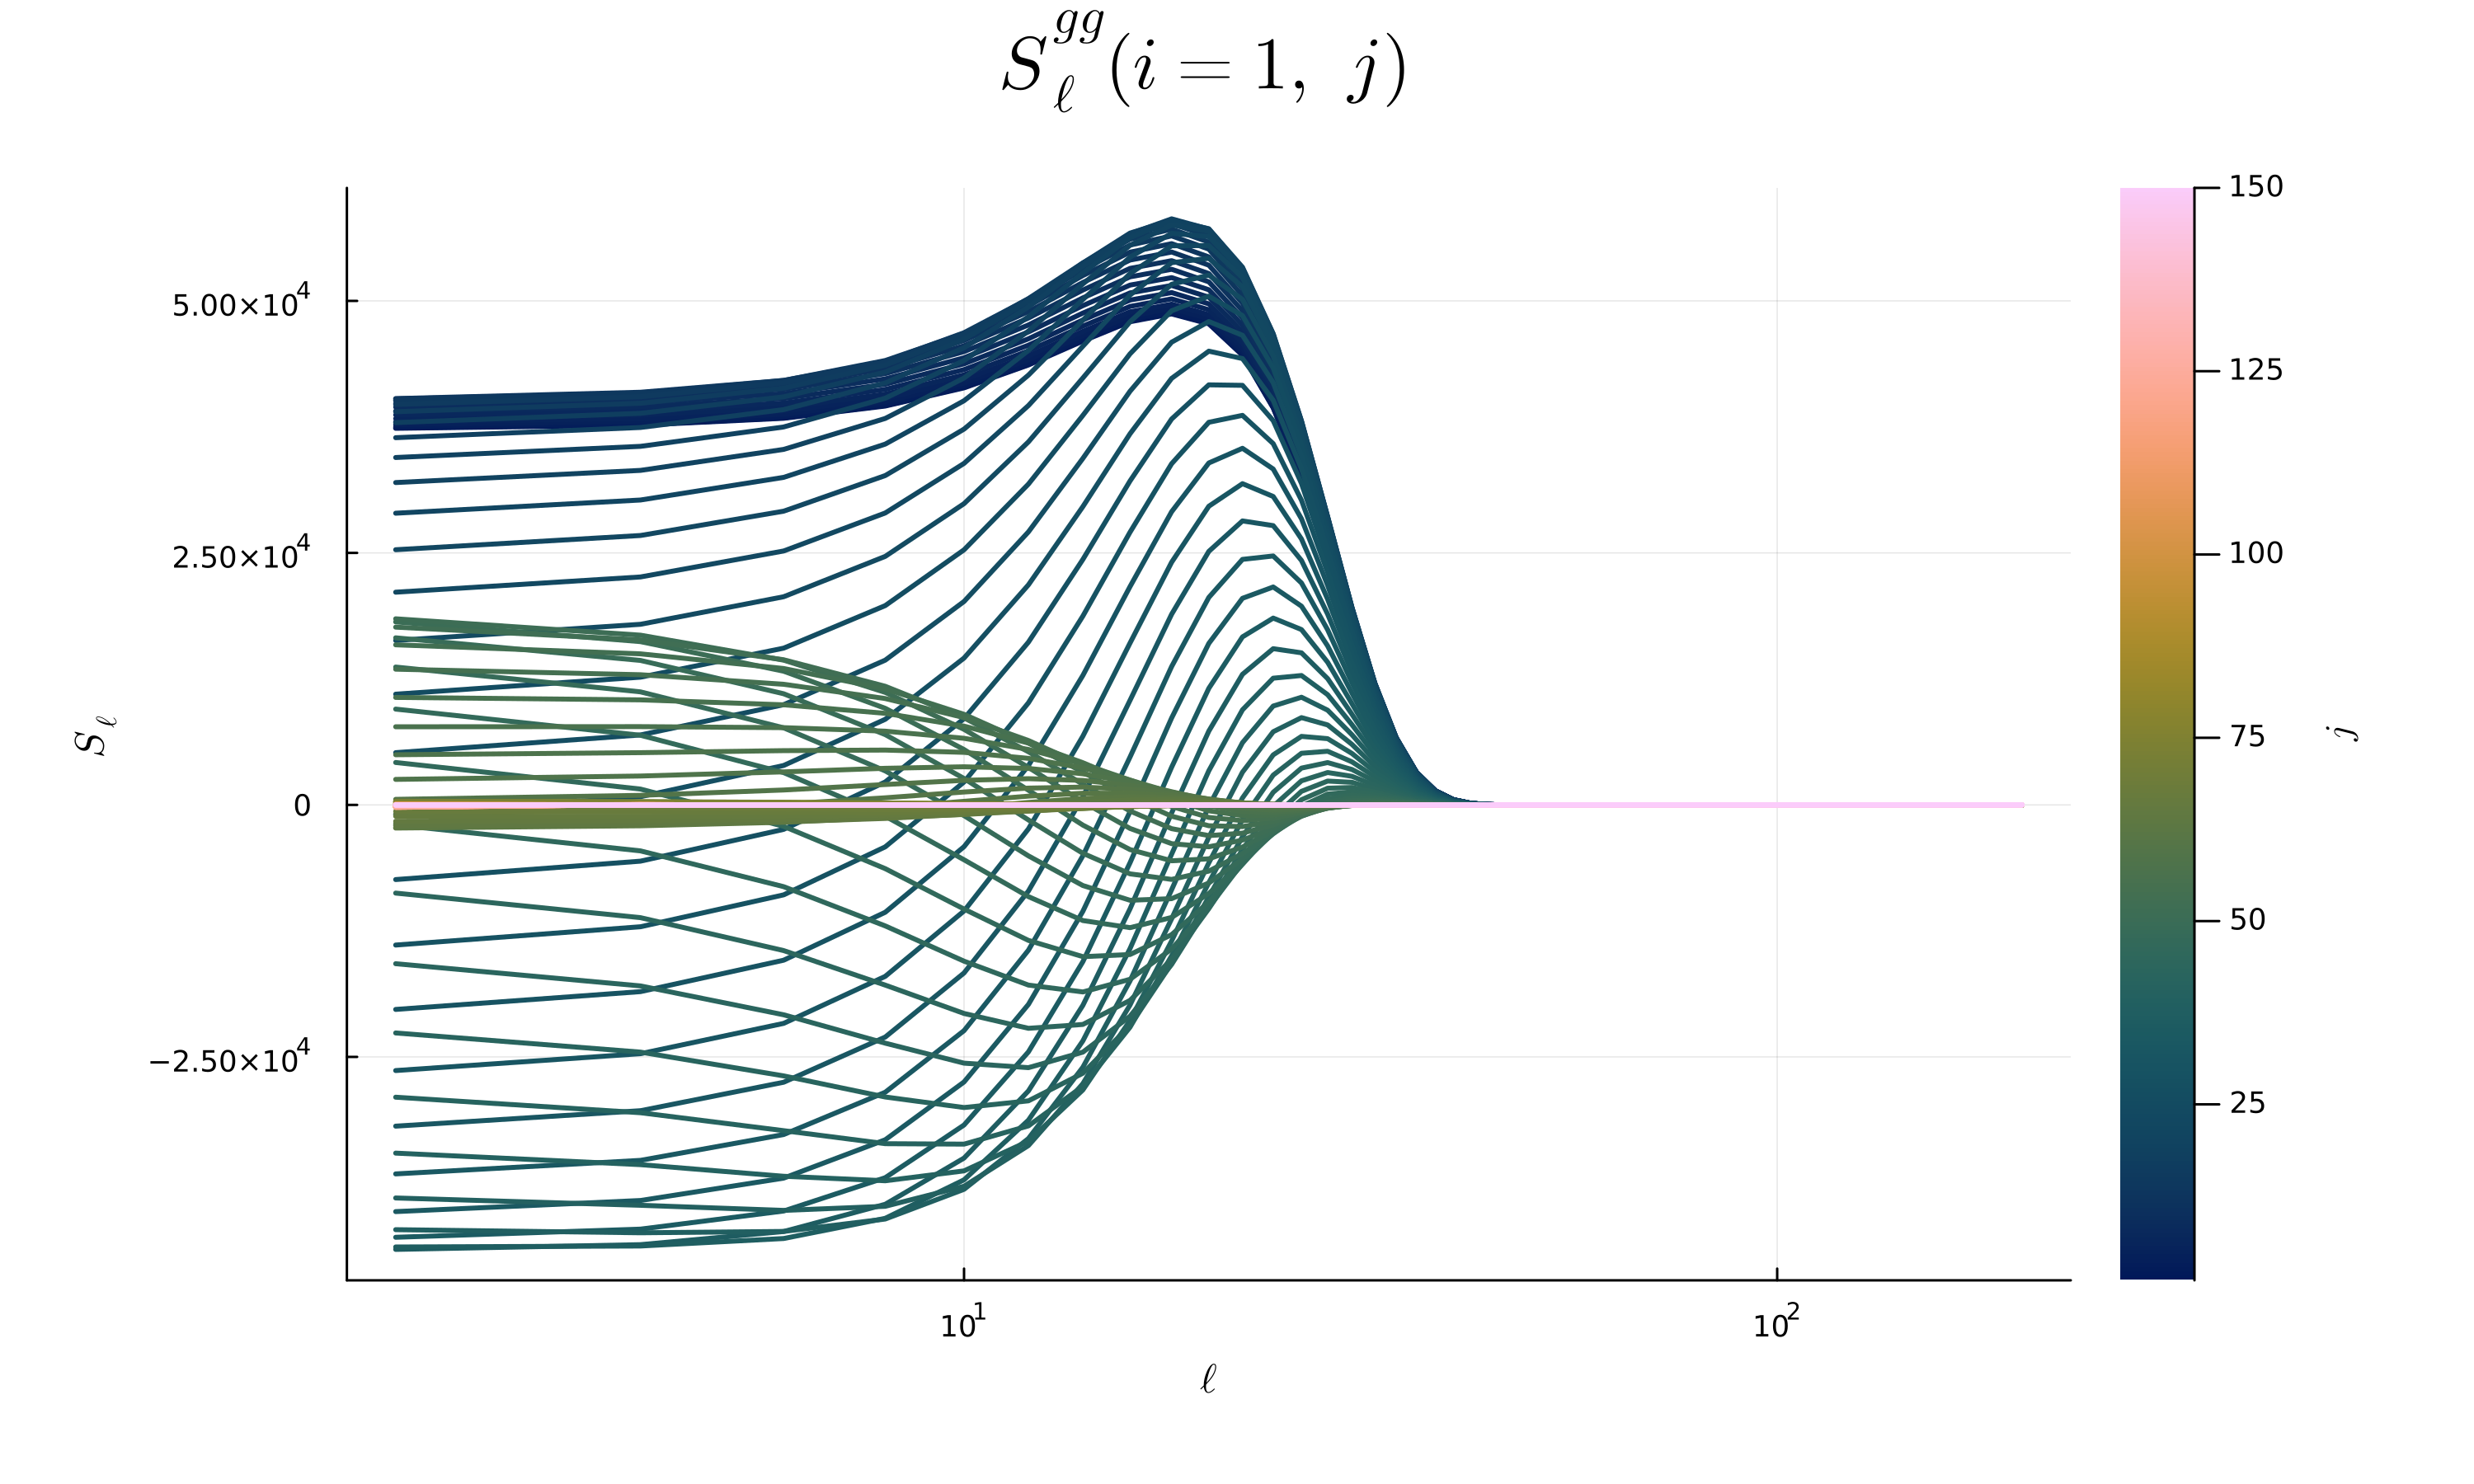

In [ ]:
plt = plot()

i_fixed = 1
for j in 1:Nkp
    plot!(plt, ℓ, S_lkk_gg[i_fixed, j, :],
          line_z = j,                  # valore costante per tutta la curva -> colore da colormap
          color = :batlow,             # palette continua usata per la colorbar
          linewidth = 2,
          label = "")                  # niente etichette singole
end

plot!(plt,
    legend = false, colorbar = true,   # colorbar al posto della legenda
    colorbar_title = L"j",
    clims = (1, Nkp),                   # range della colorbar coerente con l'indice j
    xlabel = L"\ell", ylabel = L"S_\ell",
    title = L"S_\ell^{gg} (i = 1,\ j)",
    size = size_plot, titlefontsize = 20,
    margin = 10mm,
    dpi = 300
    ,xscale = :log10
    )

plt


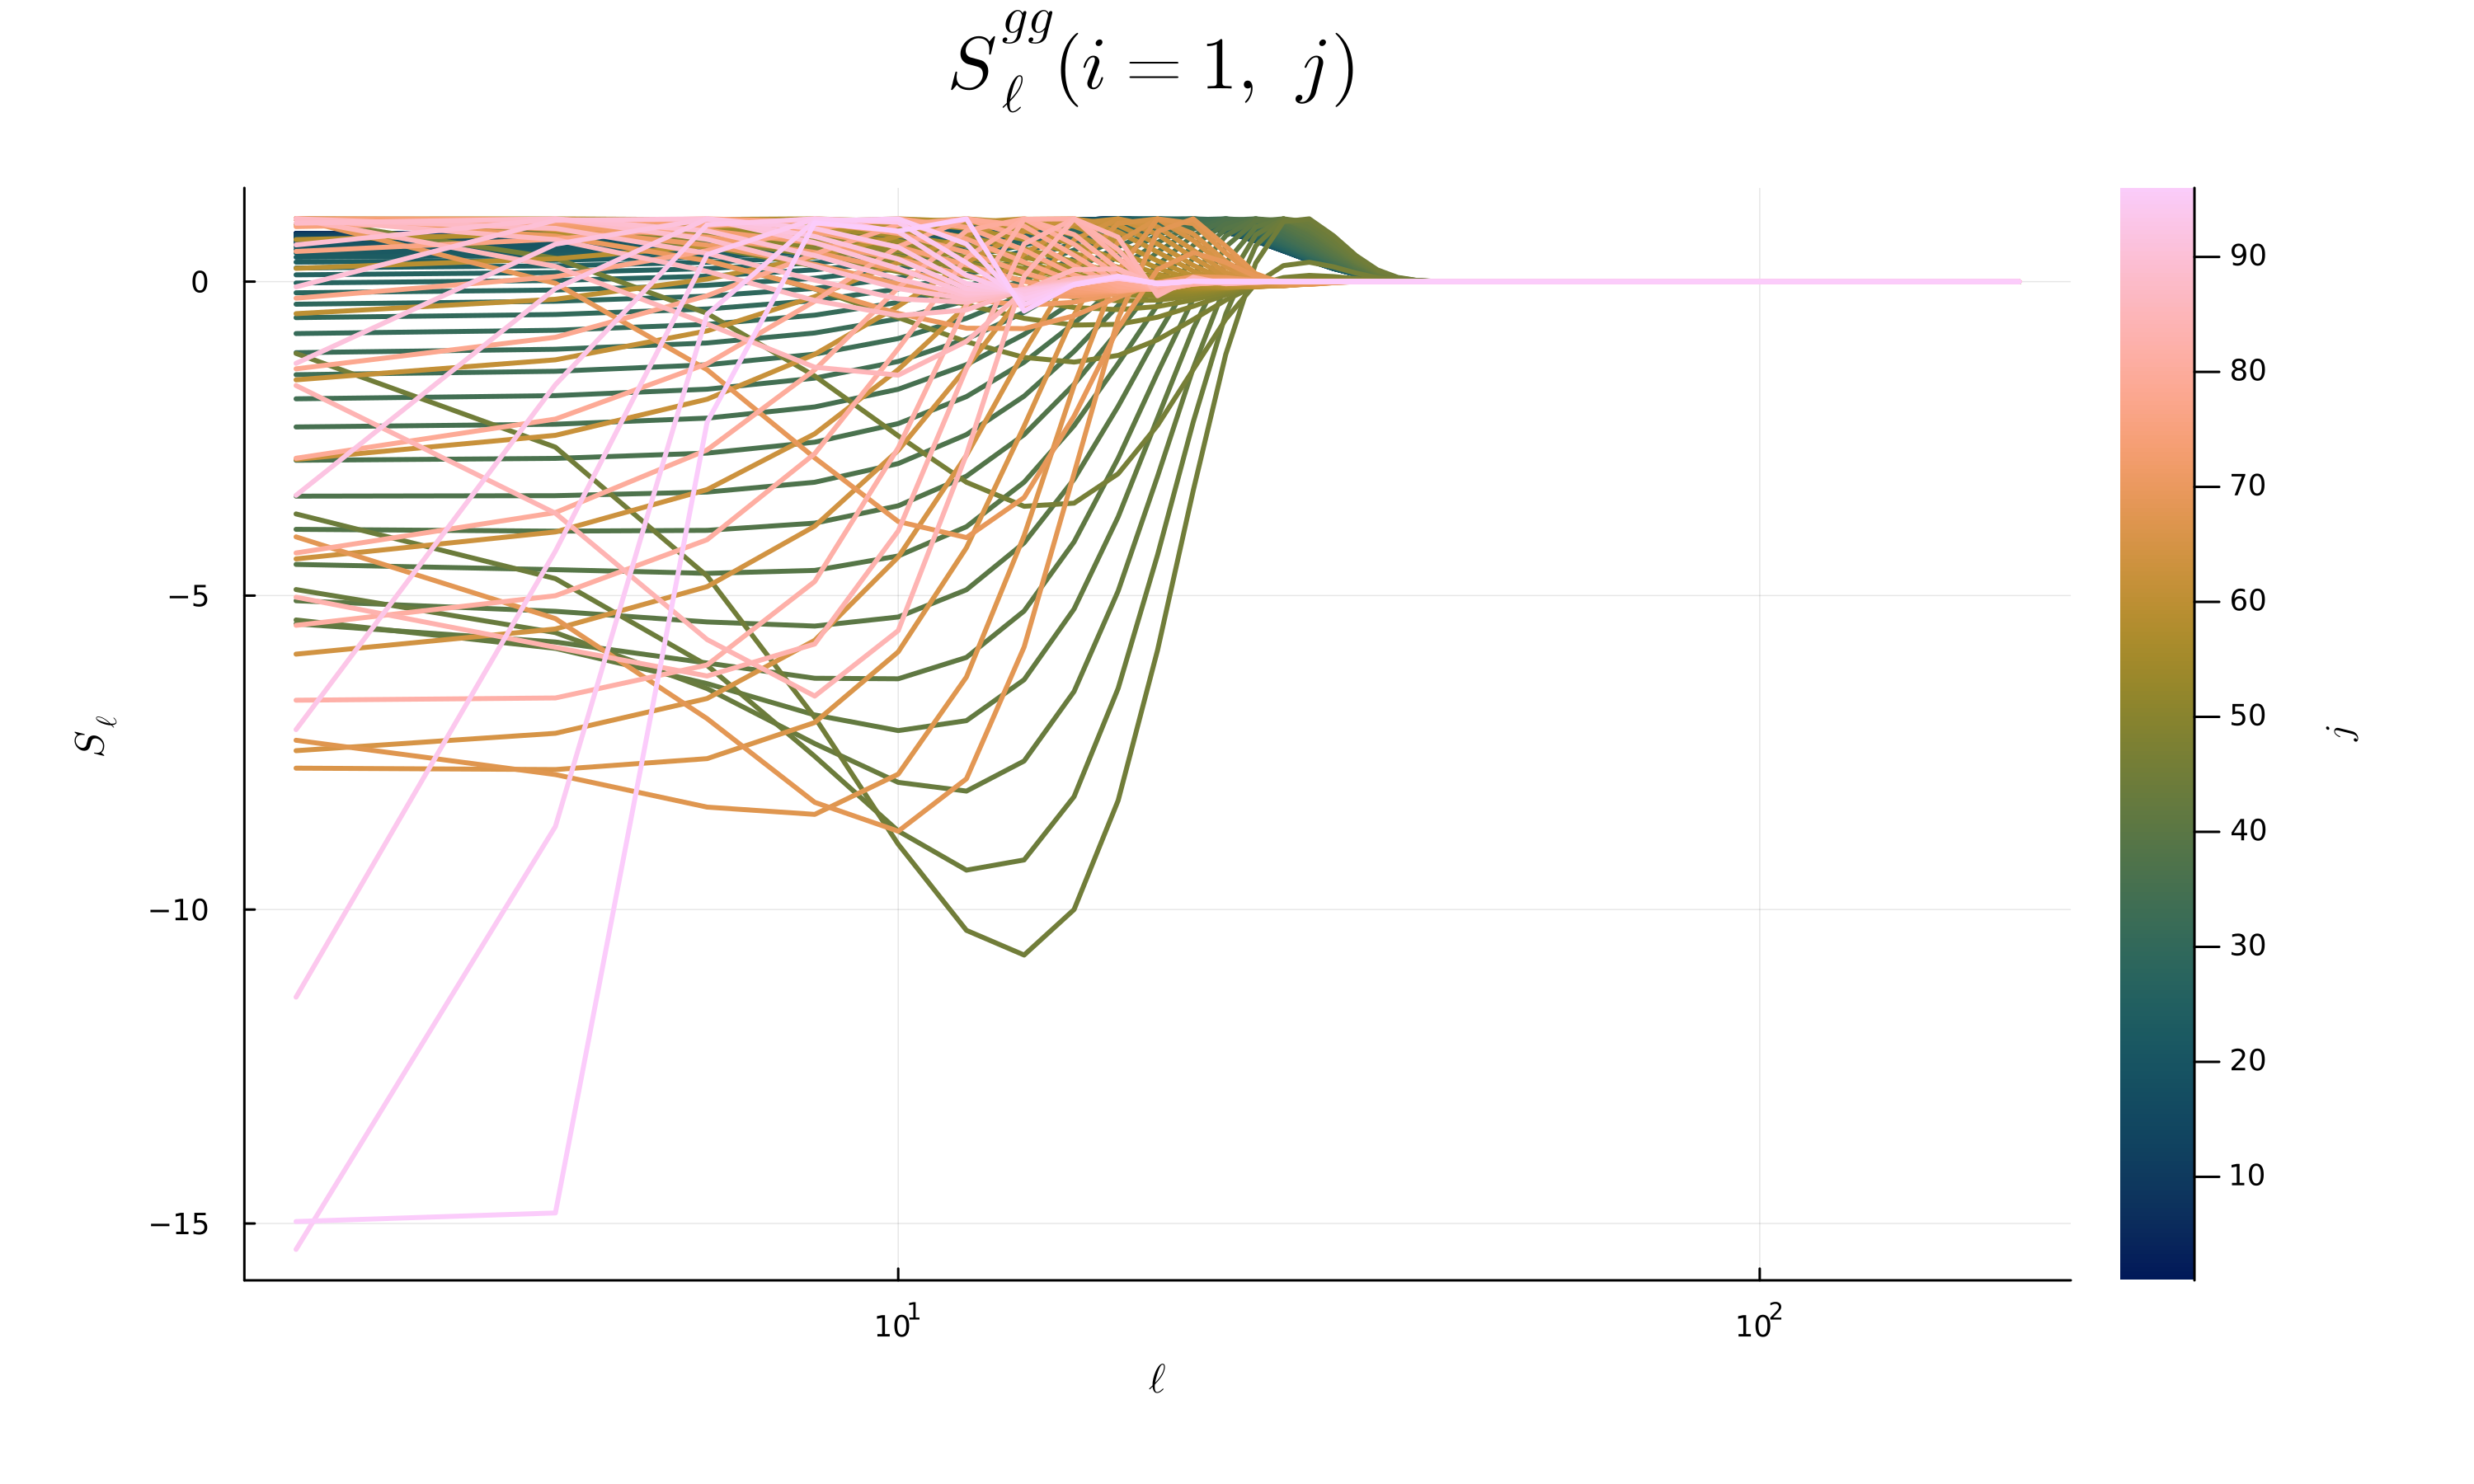

In [ ]:
plt = plot()
jj = 96
i_fixed = 1
for j in 1:jj
    plot!(plt, ℓ, S_lkk_gg[i_fixed, j, :] / maximum(S_lkk_gg[i_fixed, j, :]),
          line_z = j,                  # valore costante per tutta la curva -> colore da colormap
          color = :batlow,             # palette continua usata per la colorbar
          linewidth = 2,
          label = "")                  # niente etichette singole
end

plot!(plt,
    legend = false, colorbar = true,   
    colorbar_title = L"j",
    clims = (1, jj),                   
    xlabel = L"\ell", ylabel = L"S_\ell",
    title = L"S_\ell^{gg} (i = 1,\ j)",
    size = size_plot, titlefontsize = 20,
    margin = 10mm,
    dpi = 300
    ,xscale = :log10
    )

plt


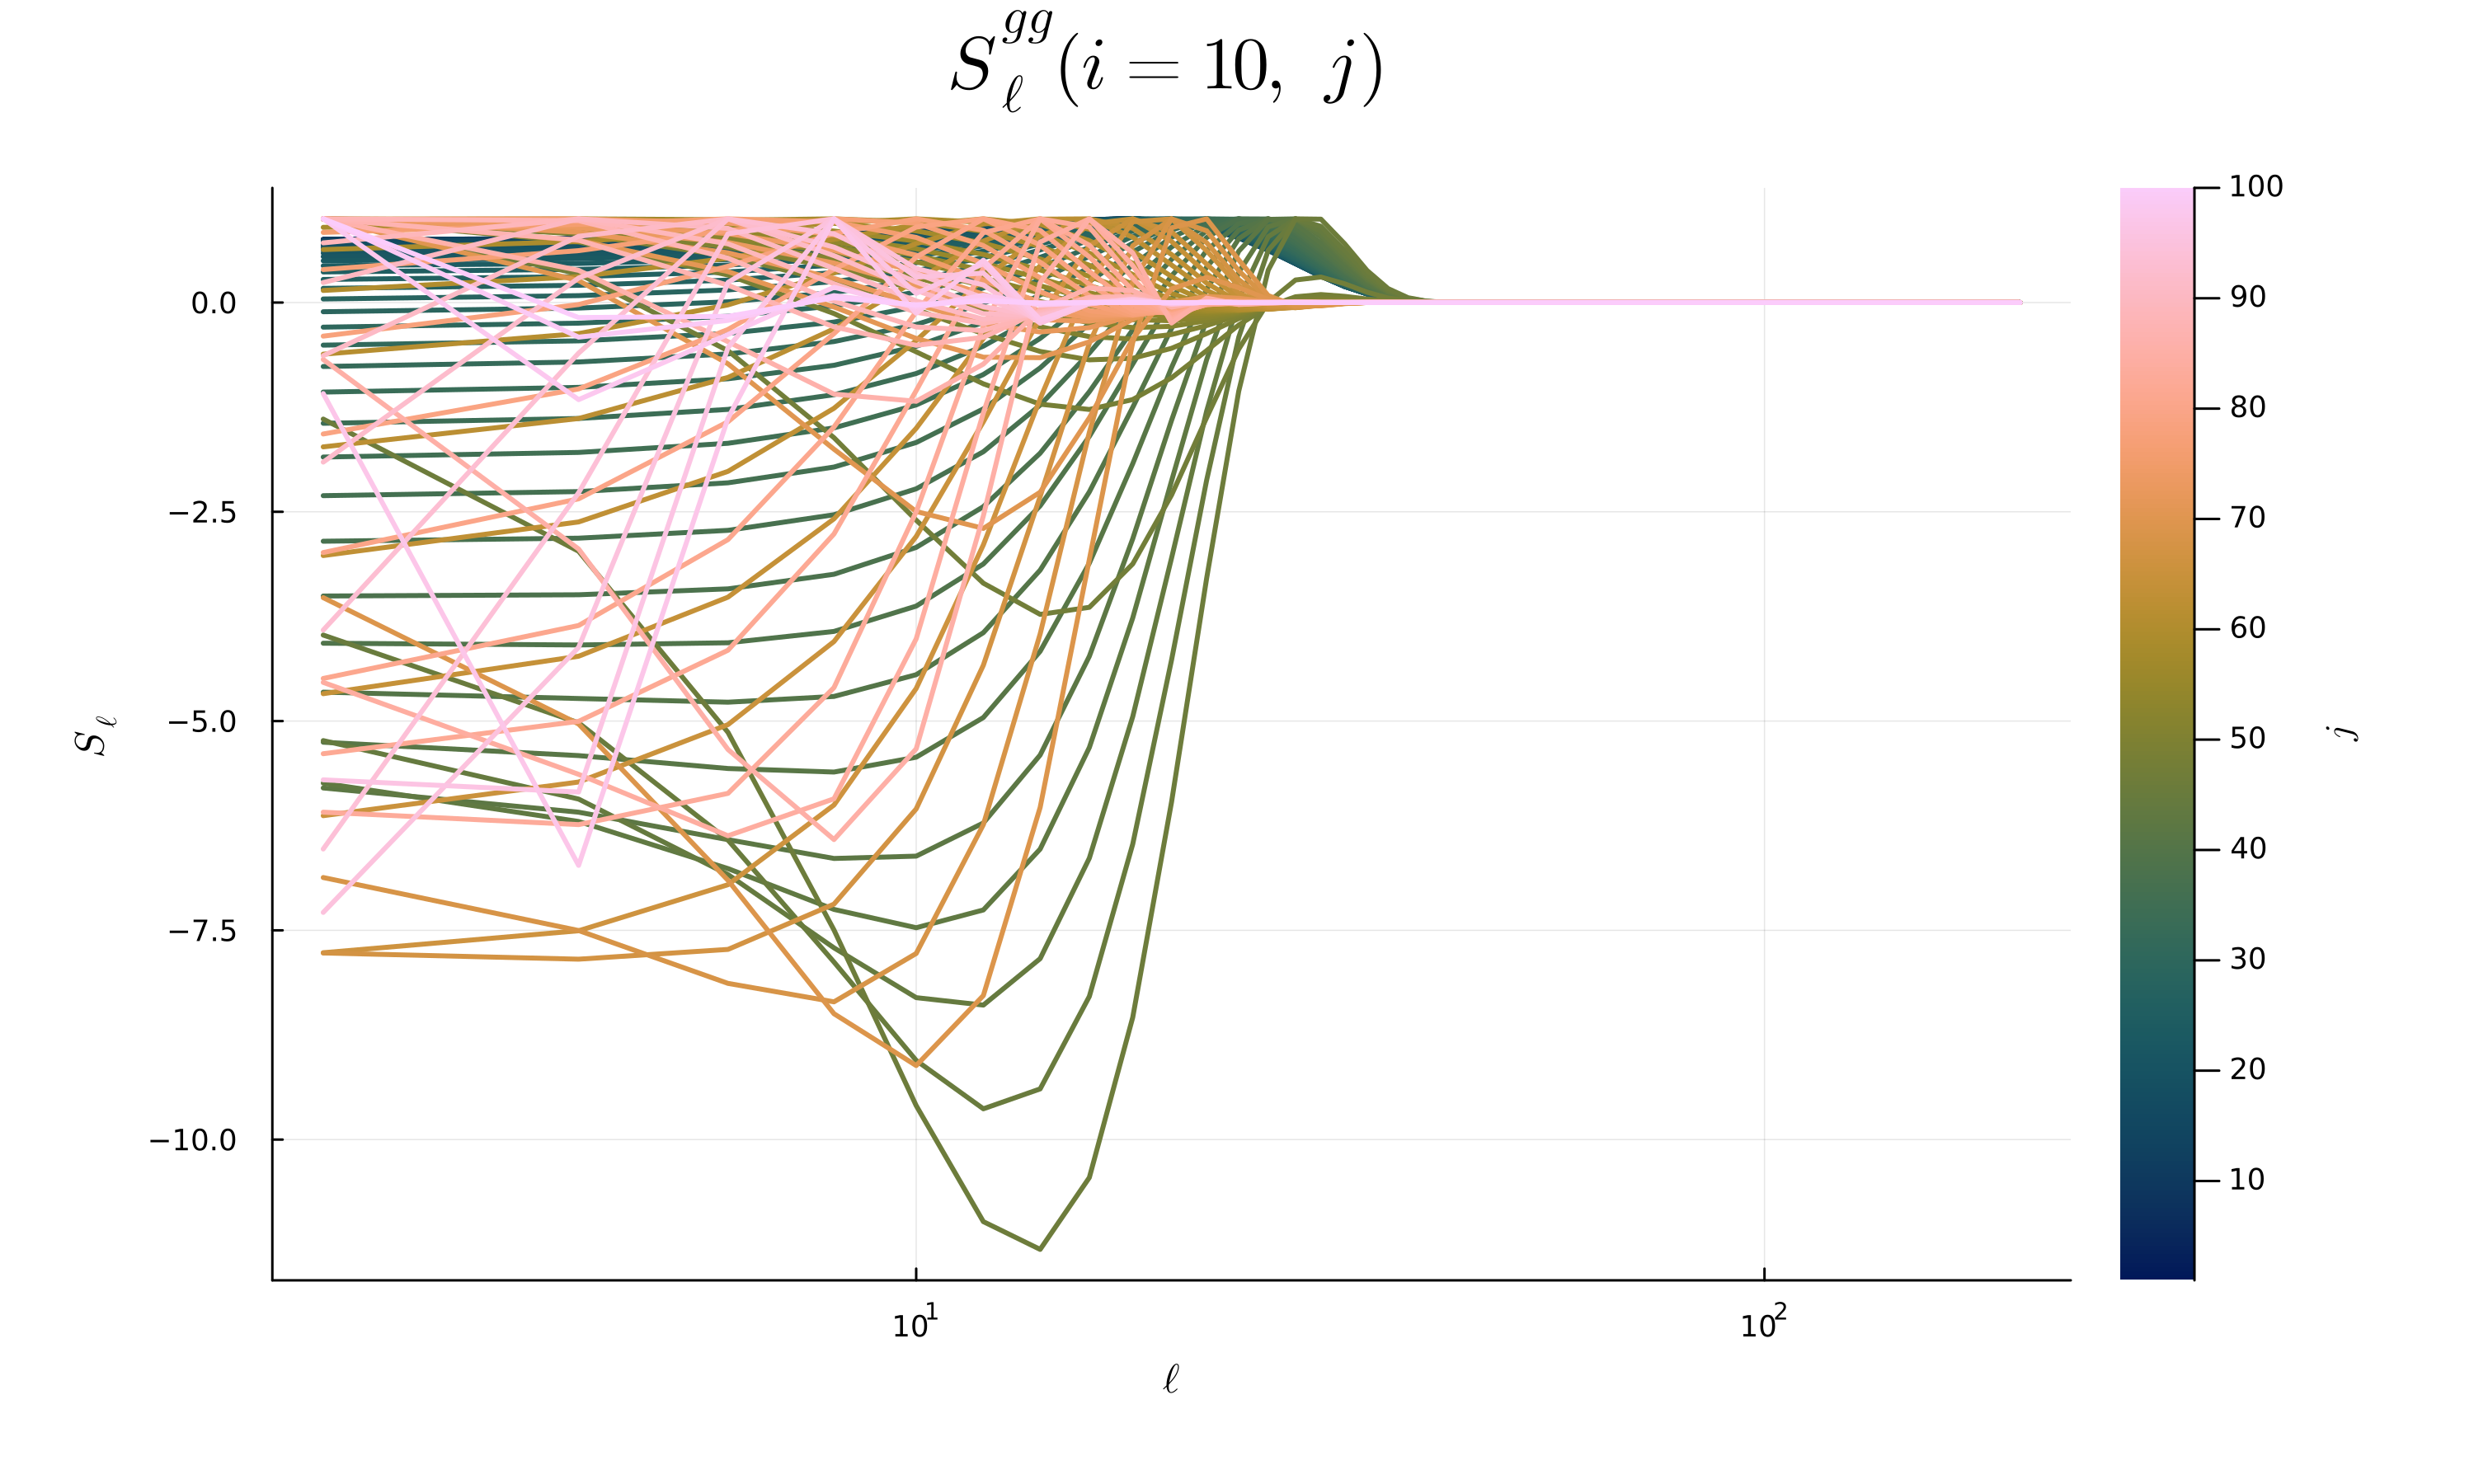

In [ ]:
plt = plot()
jj = 100
i_fixed = 10
for j in 1:jj
    plot!(plt, ℓ, S_lkk_gg[i_fixed, j, :] / maximum(S_lkk_gg[i_fixed, j, :]),
          line_z = j,                  # valore costante per tutta la curva -> colore da colormap
          color = :batlow,             # palette continua usata per la colorbar
          linewidth = 2,
          label = "")                  # niente etichette singole
end

plot!(plt,
    legend = false, colorbar = true,   # colorbar al posto della legenda
    colorbar_title = L"j",
    clims = (1, jj),                   # range della colorbar coerente con l'indice j
    xlabel = L"\ell", ylabel = L"S_\ell",
    title = L"S_\ell^{gg} (i = 10,\ j)",
    size = size_plot, titlefontsize = 20,
    margin = 10mm,
    dpi = 300
    ,xscale = :log10
    )

plt


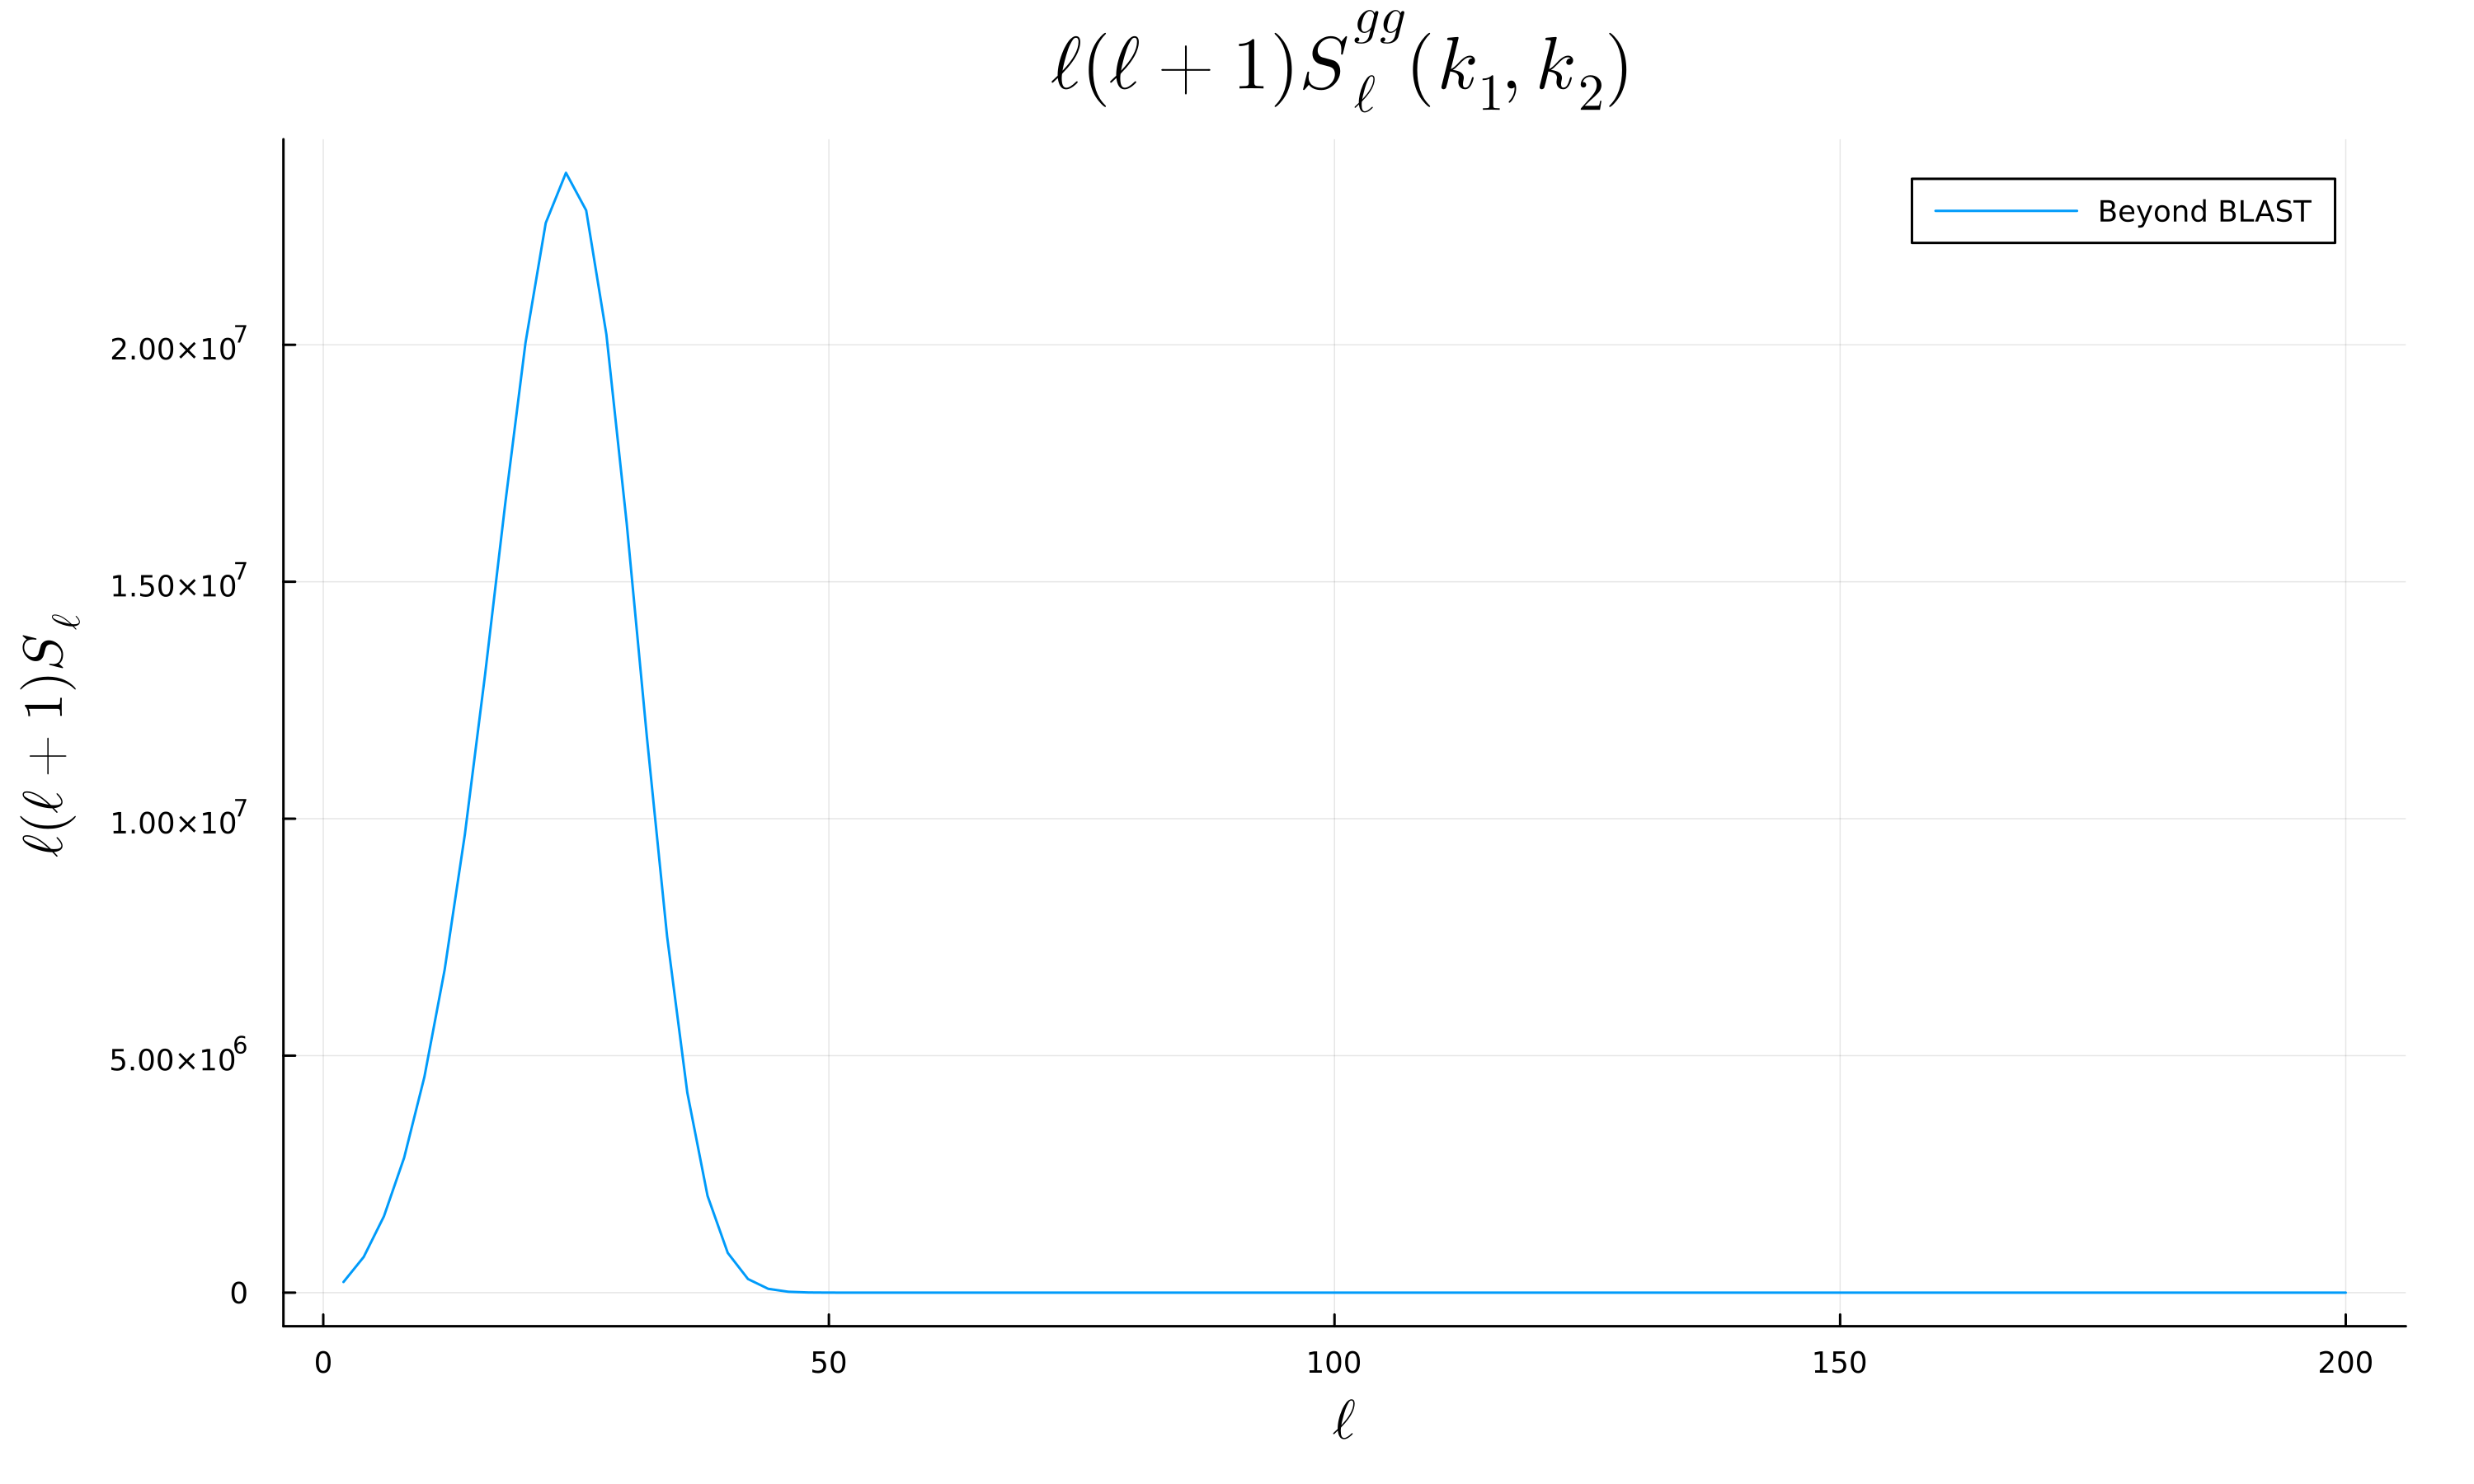

In [ ]:
plot(
    ℓ,
    S_lkk_gg[1, 1, :] .* ℓ .* (ℓ .+ 1),
    label = "Beyond BLAST",
    xlabel = L"\ell",
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}(k_1,k_2)",
    markersize=4,
    size = size_plot,
    titlefontsize=20,
    labelfontsize=15,
    margin = 5mm,
    dpi = 300
)

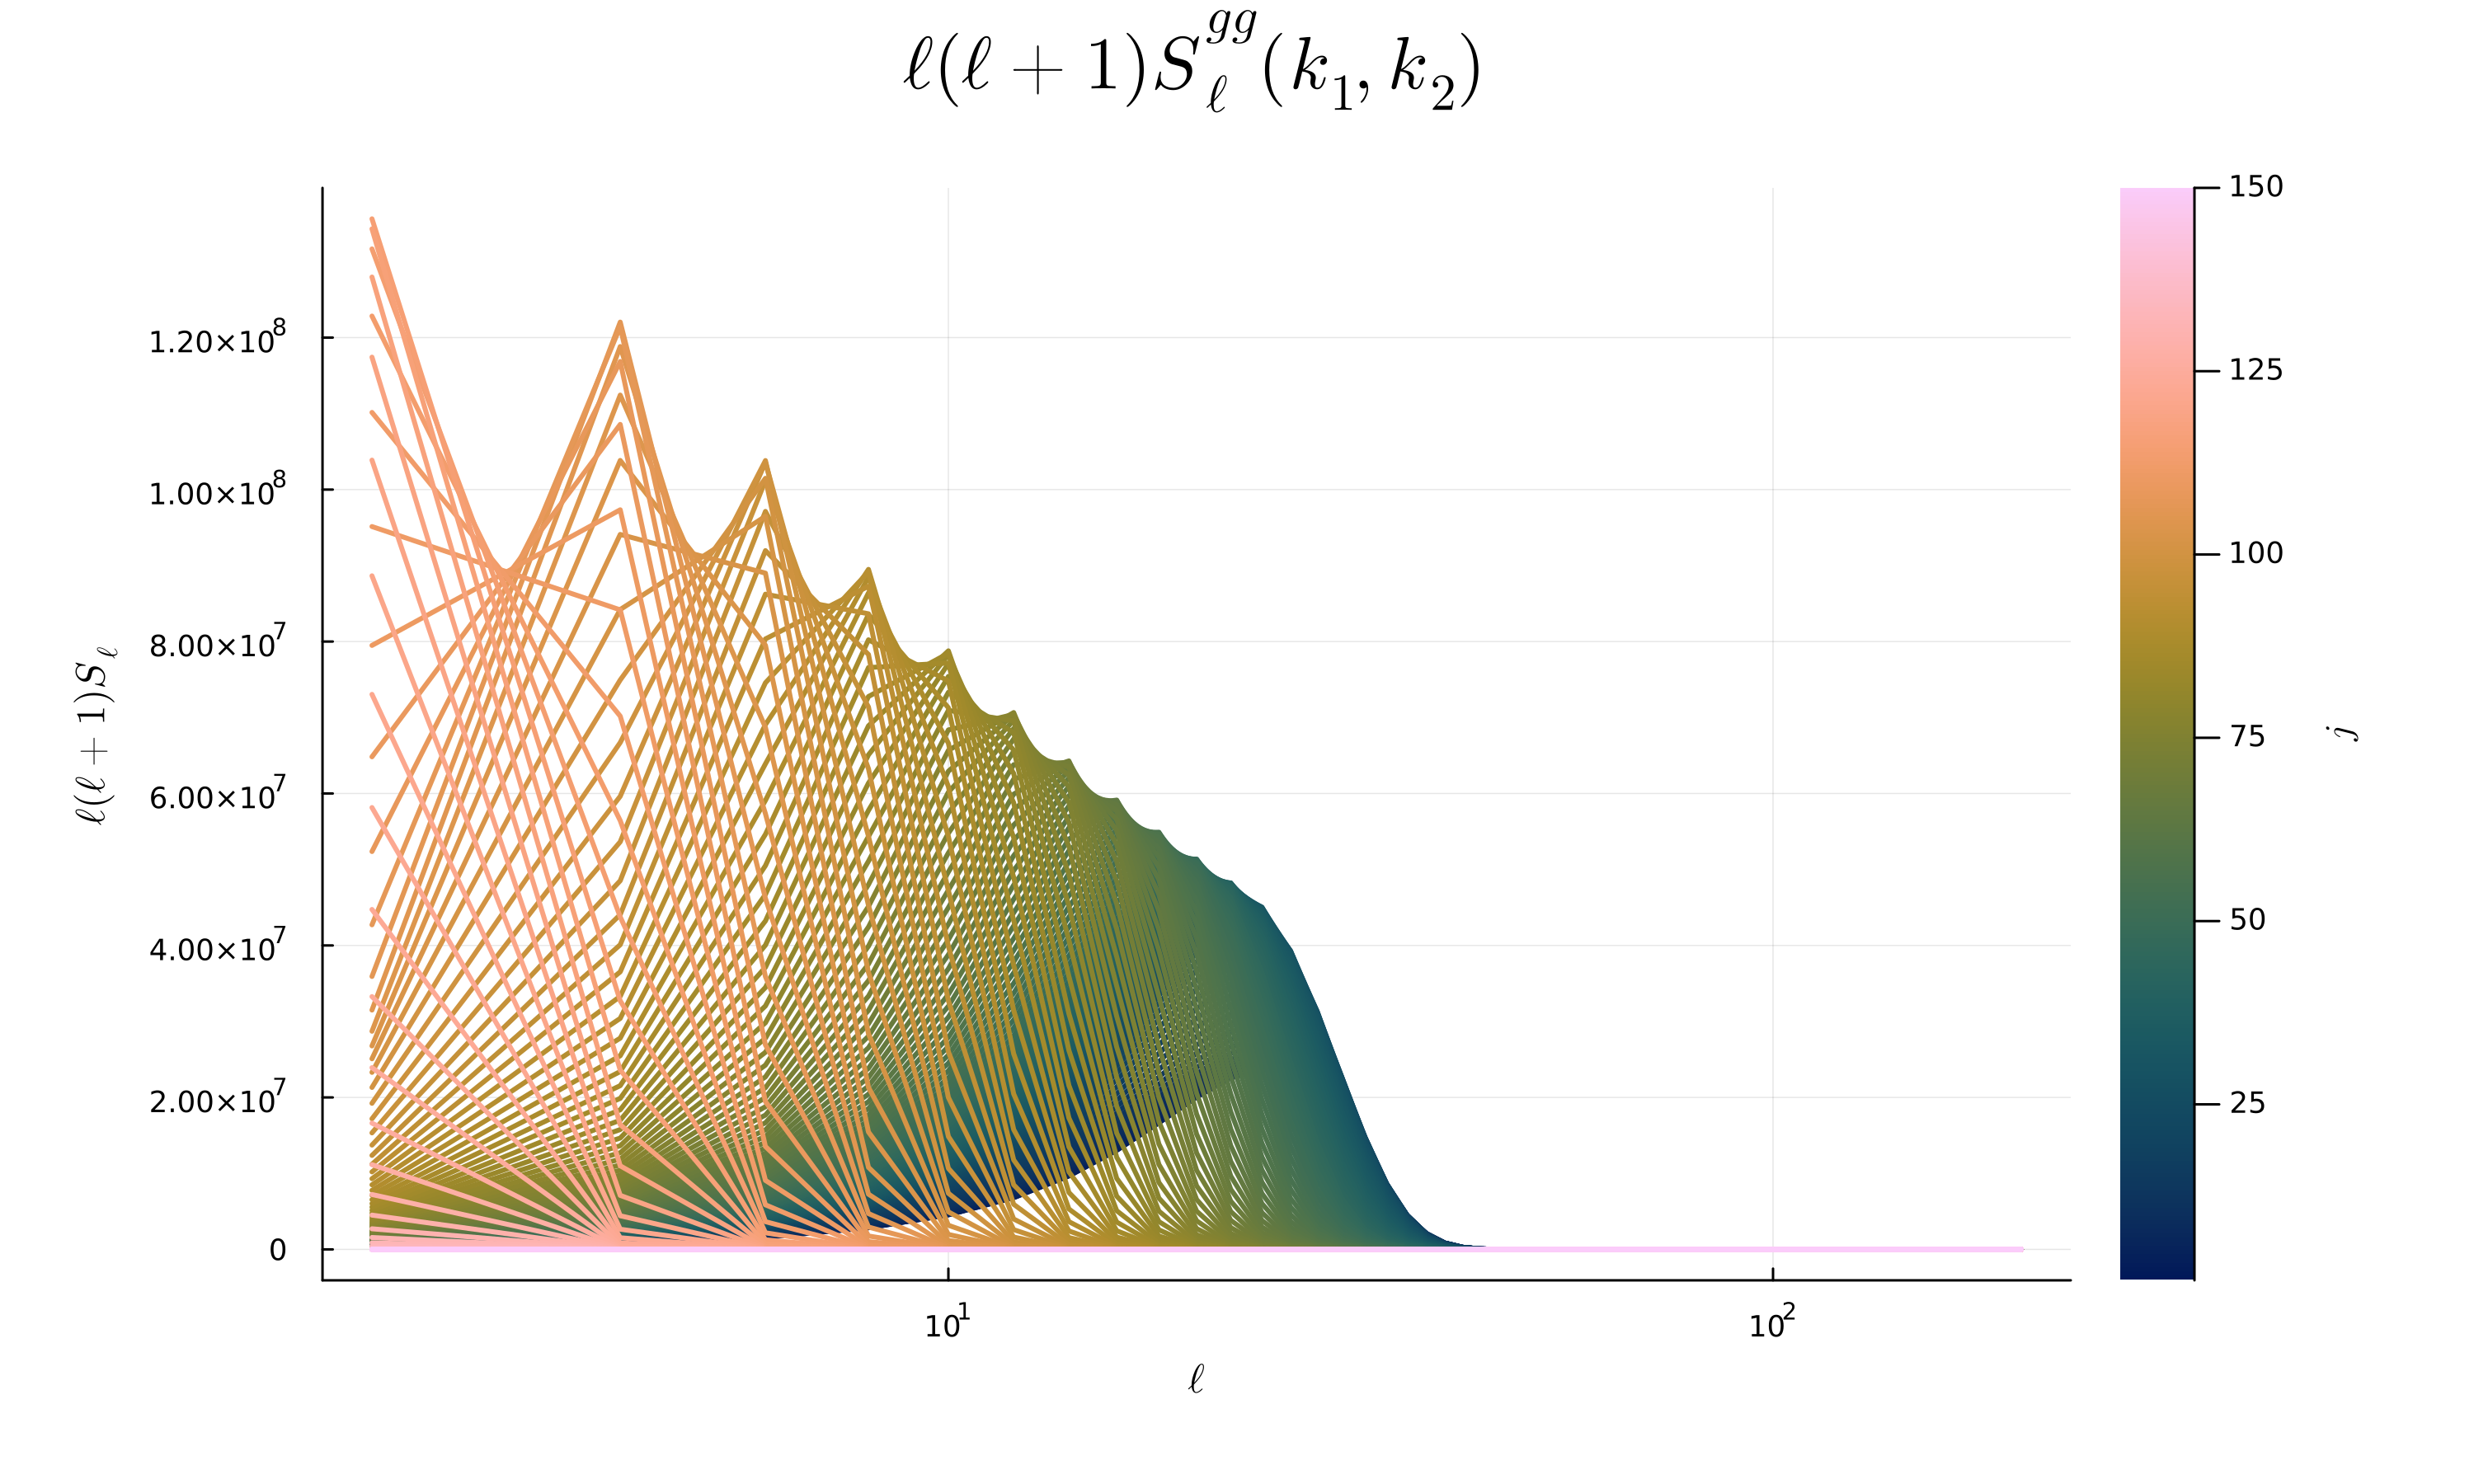

In [ ]:
plt = plot()

for j in 1:Nkp
    plot!(plt, ℓ, S_lkk_gg[j, j, :] .* ℓ .* (ℓ .+ 1),
          line_z = j,                  # valore costante per tutta la curva -> colore da colormap
          color = :batlow,             # palette continua usata per la colorbar
          linewidth = 2,
          label = "")                  # niente etichette singole
end

plot!(plt,
    legend = false, colorbar = true,   # colorbar al posto della legenda
    colorbar_title = L"j",
    clims = (1, Nkp),                   # range della colorbar coerente con l'indice j
    xlabel = L"\ell", 
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}(k_1,k_2)",
    size = size_plot, titlefontsize = 20,
    margin = 10mm,
    dpi = 300
    ,xscale = :log10
    )

plt

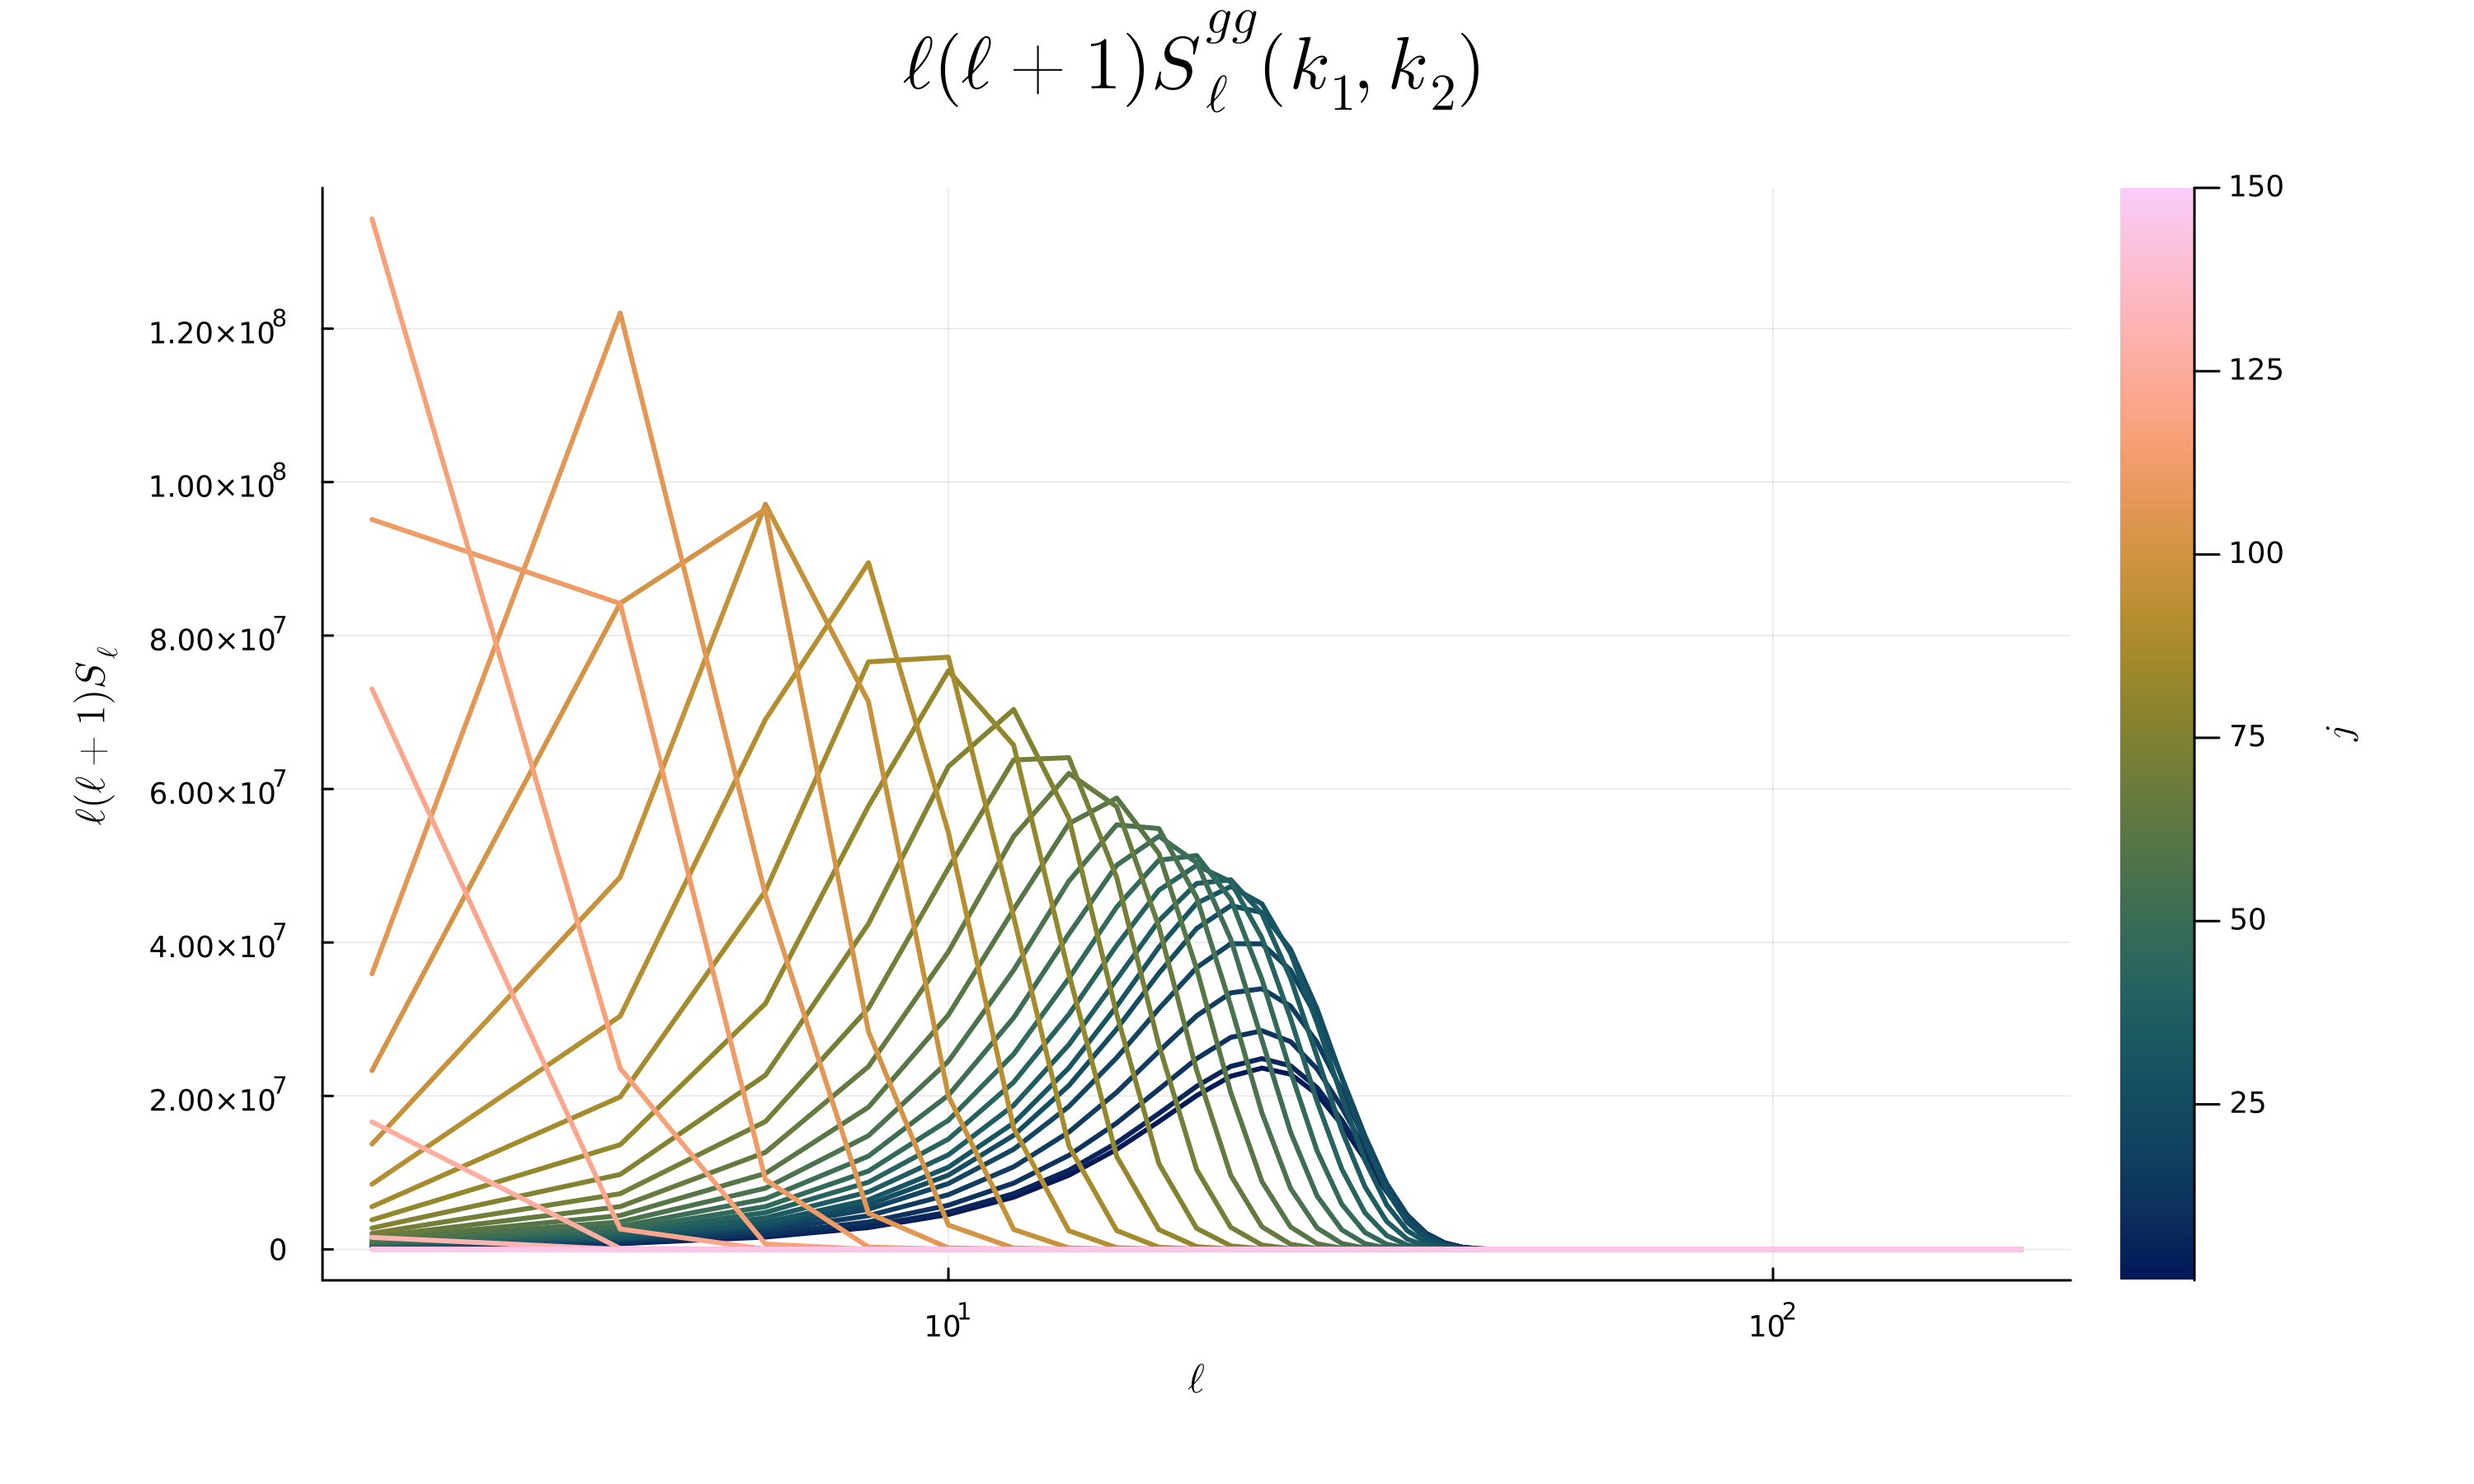

In [ ]:
plt = plot()

for j in a
    plot!(plt, ℓ, S_lkk_gg[j, j, :] .* ℓ .* (ℓ .+ 1),
          line_z = j,                  # valore costante per tutta la curva -> colore da colormap
          color = :batlow,             # palette continua usata per la colorbar
          linewidth = 2,
          label = "")                  # niente etichette singole
end

plot!(plt,
    legend = false, colorbar = true,   # colorbar al posto della legenda
    colorbar_title = L"j",
    clims = (1, Nkp),                   # range della colorbar coerente con l'indice j
    xlabel = L"\ell", 
    ylabel = L"\ell(\ell+1)S_\ell",
    title = L"\ell(\ell+1)S_\ell^{gg}(k_1,k_2)",
    size = size_plot, titlefontsize = 20,
    margin = 10mm,
    dpi = 300
    ,xscale = :log10
    )

plt

In [900]:
println(size(S_lkk_gg))

(150, 150, 100)


Size of S_lkk_gg: (150, 150, 100)
Size of diagS: (100,)
Size of k_grid: (150,)


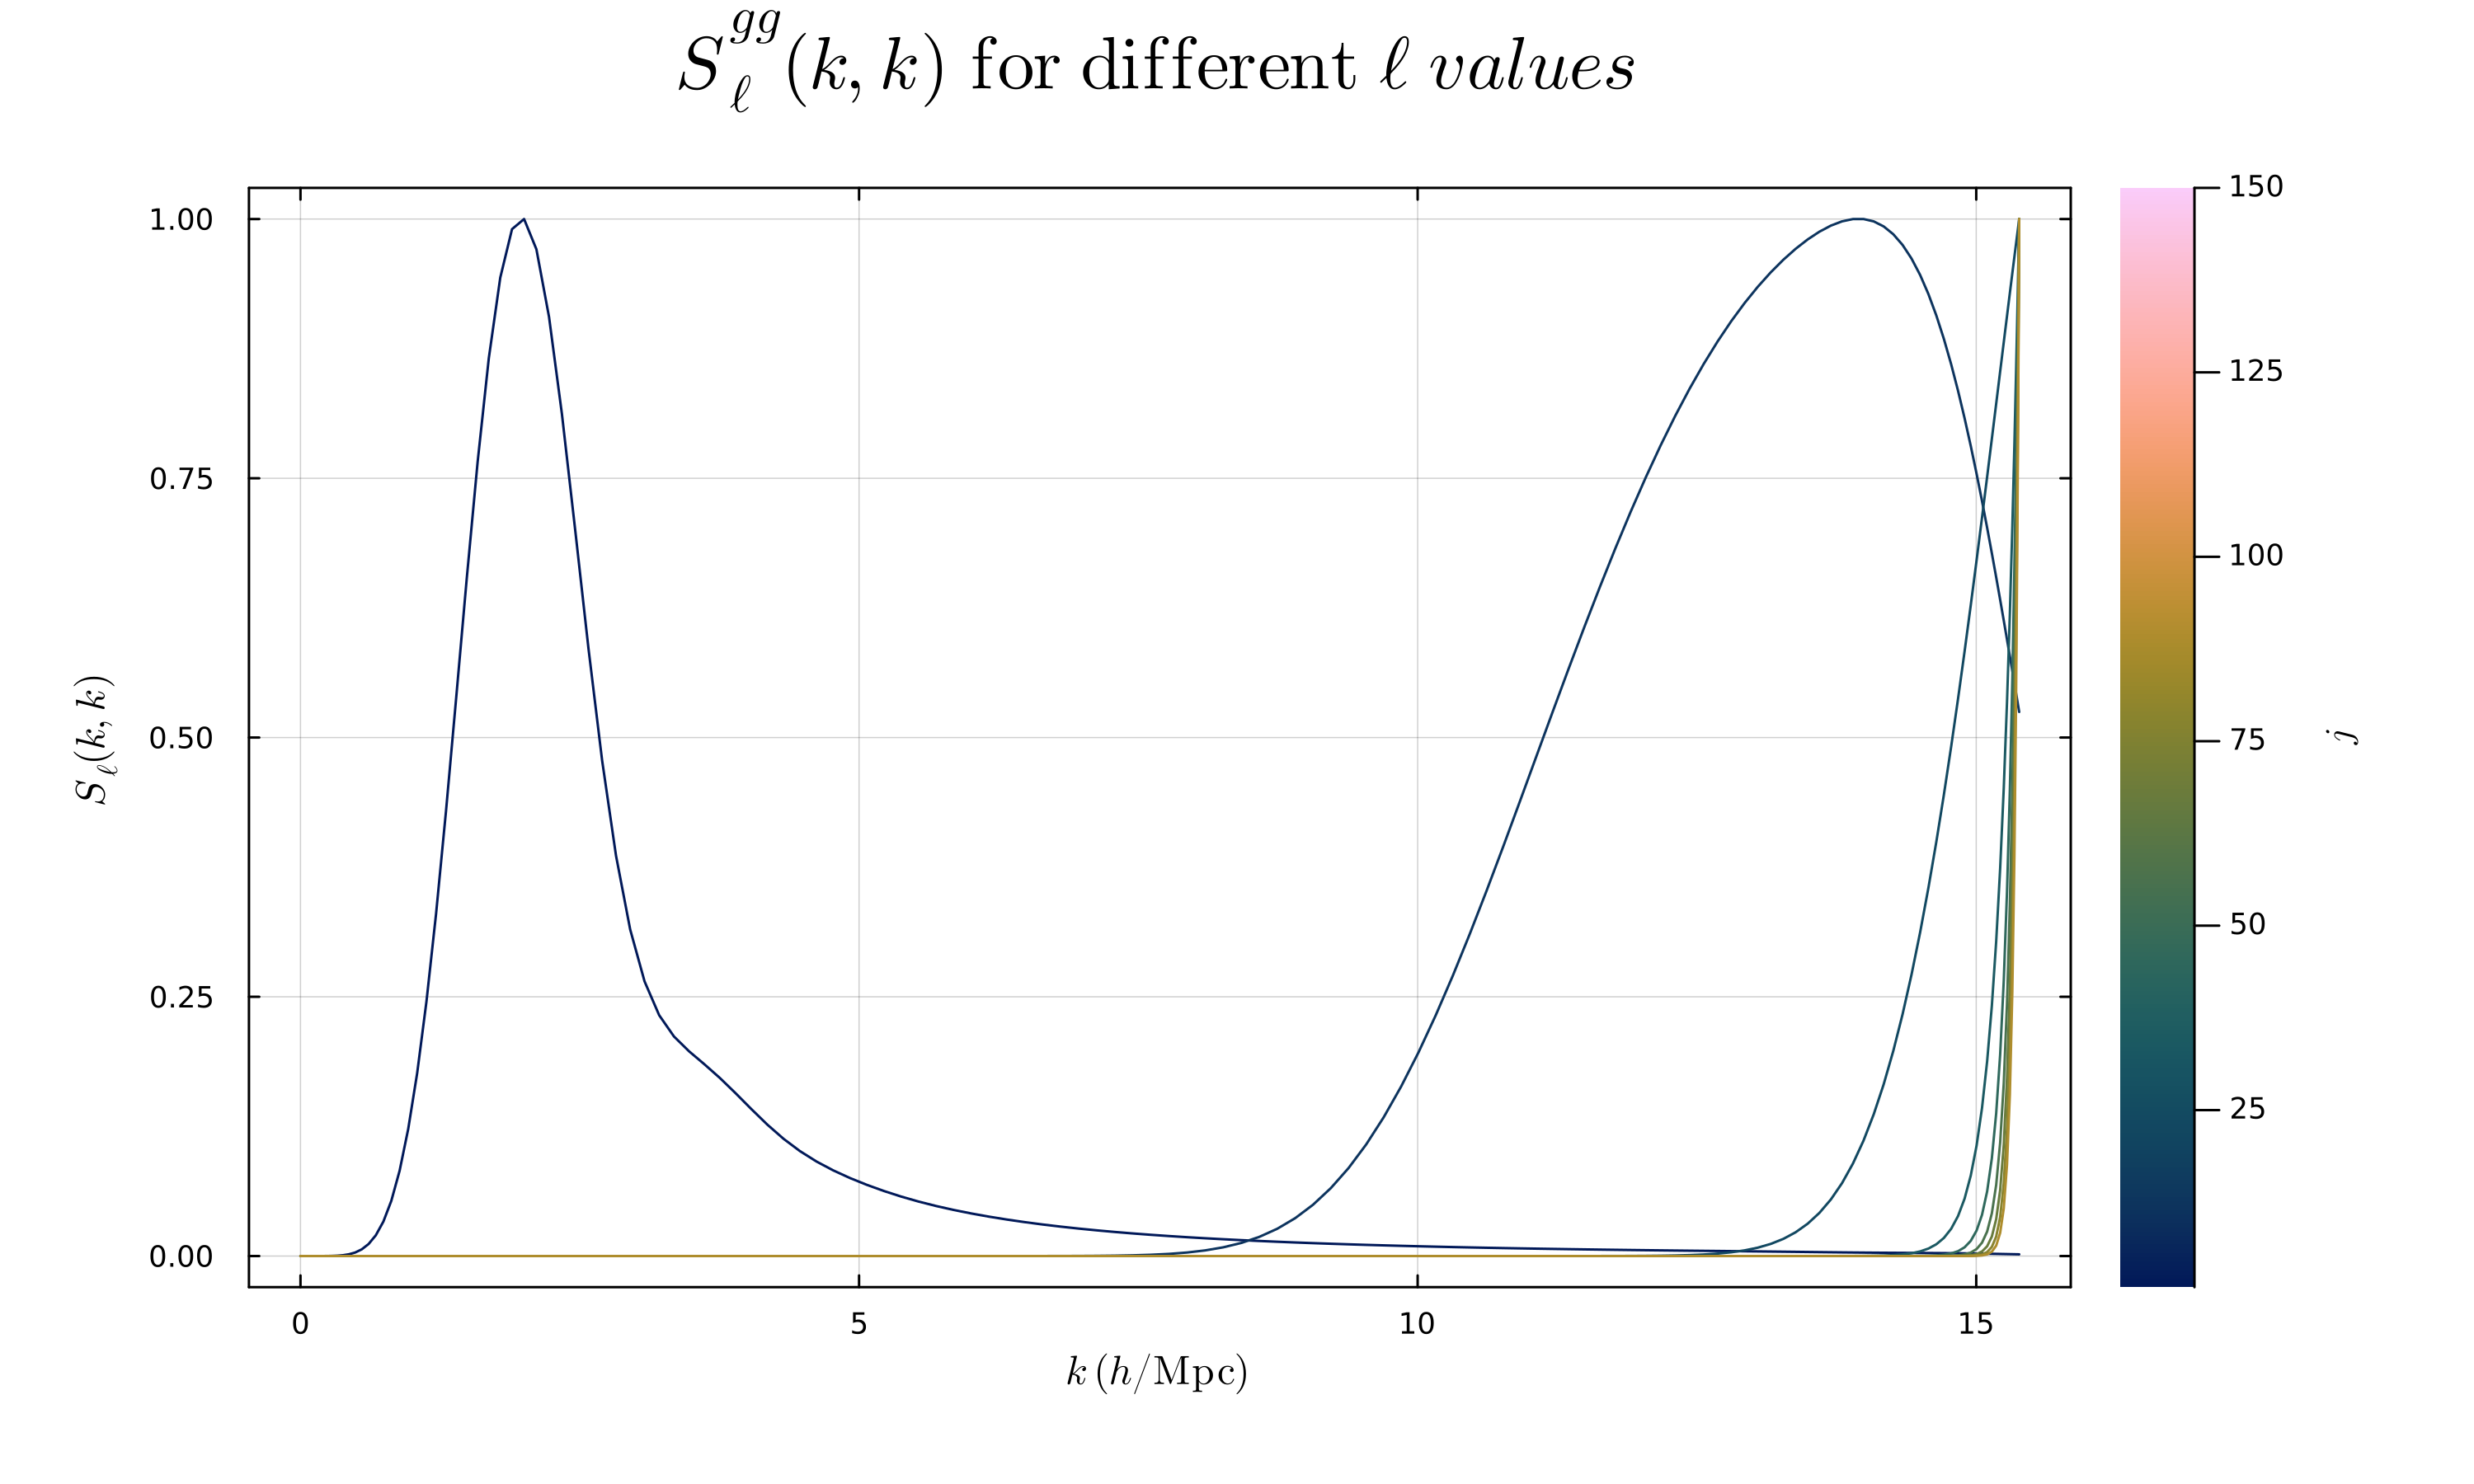

In [ ]:
diagS = [diag(@view S_lkk_gg[:, :, i]) for i in 1:size(S_lkk_gg, 3)]

println("Size of S_lkk_gg: ", size(S_lkk_gg))
println("Size of diagS: ", size(diagS))
println("Size of k_grid: ", size(k_grid))

nshow = 10
idx = round.(Int, range(1, size(S_lkk_gg, 3), length=nshow))

pp = plot(
    #xscale = :log10,
    #yscale = :log10,
    xlabel = L"k \; (h/\mathrm{Mpc})",
    ylabel = L"S_\ell(k,k)",
    title  = L"S_\ell^{gg}(k,k)\ \mathrm{for\ different}\ \ell\ values",
    clims = (1, 150),                   # range della colorbar coerente con l'indice j
    colorbar_title = L"j",
    legend = false,
    colorbar = true,
    framestyle = :box,
    grid = true,
    lw = 2,
    size = size_plot,
    titlefontsize = 20,
    margin = 10mm,
    dpi = 300
)

for ii in idx
    plot!(pp, kp_grid, diagS[ii]/maximum(diagS[ii]), line_z = ii, color = :batlow;
        label = L"\ell = %$(ℓ[ii])")
end

pp


---